# Marketing Campaign Analysis — Exploratory Data Analysis

**Notebook 03 di 05** · Analisi esplorativa approfondita sul dataset pulito

## Obiettivo di questo notebook
Dopo aver pulito il dataset nel Notebook 02, entriamo nel vivo dell'analisi esplorativa. L'obiettivo è **ascoltare i dati**: individuare pattern, distribuzioni, correlazioni e anomalie che guideranno le scelte di segmentazione nel Notebook 04 e l'analisi di efficacia delle campagne nel Notebook 05.

## Struttura
1. **Setup** e caricamento del dataset pulito
2. **Analisi univariate — demografia**: come sono distribuiti i nostri clienti per età, reddito, istruzione, stato civile, composizione familiare
3. **Analisi univariate — comportamento di spesa**: quanto spendono e su quali categorie di prodotto
4. **Analisi univariate — canali e campagne**: dove acquistano e come rispondono alle promozioni
5. **Analisi bivariate — le relazioni chiave**: come interagiscono le variabili tra loro (es. reddito vs spesa, età vs canali preferiti)
6. **Matrice di correlazione**: una visione d'insieme delle relazioni numeriche
7. **Sintesi e ipotesi** per la fase di segmentazione

## Cosa NON faremo qui
- Non costruiremo segmenti di clienti (→ Notebook 04)
- Non valuteremo l'efficacia delle campagne per segmento (→ Notebook 05)
- Non faremo modellazione predittiva

L'EDA serve a **generare ipotesi**, non a validarle. Ogni pattern che troviamo oggi diventerà una domanda da investigare nei notebook successivi.

---

## 0. Setup: librerie e caricamento del dataset pulito

Carichiamo il dataset pulito generato dal Notebook 02 (`marketing_campaign_clean.csv`). Questo notebook è **indipendente** dai precedenti: parte dal dataset processato, non dal raw. È una buona pratica di riproducibilità — se qualcuno vuole eseguire solo l'EDA, può farlo senza rieseguire il cleaning.

In [1]:
# Librerie di data manipulation
import pandas as pd
import numpy as np

# Librerie di visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazioni pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Configurazioni estetiche globali per i grafici
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)   # dimensione default
plt.rcParams['axes.titlesize'] = 13         # titoli un po' piu grandi
plt.rcParams['axes.labelsize'] = 11         # label assi

print("Librerie importate correttamente")
print(f"   pandas:     {pd.__version__}")
print(f"   numpy:      {np.__version__}")
print(f"   seaborn:    {sns.__version__}")

Librerie importate correttamente
   pandas:     3.0.2
   numpy:      2.4.3
   seaborn:    0.13.2


In [2]:
# Path al dataset pulito generato dal Notebook 02
DATA_PATH = '../data/marketing_campaign_clean.csv'

# Caricamento — specifichiamo il parse della colonna datetime
df = pd.read_csv(DATA_PATH)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

# Verifica struttura
print(f"Dataset caricato: {df.shape[0]:,} righe x {df.shape[1]} colonne")
print(f"Range temporale:  {df['Dt_Customer'].min().date()} -> {df['Dt_Customer'].max().date()}")
print(f"Missing values:   {df.isna().sum().sum()} (atteso: 0)")

Dataset caricato: 2,236 righe x 34 colonne
Range temporale:  2012-07-30 -> 2014-06-29
Missing values:   0 (atteso: 0)


In [3]:
# Prime 3 righe — con focus sulle feature derivate
cols_interesse = ['ID', 'Age', 'Income', 'Education', 'Marital_Status',
                  'Family_Size', 'Has_Children', 'MntTotal', 'TotalPurchases',
                  'TotalCampaignsAccepted', 'Customer_Tenure_Days']
df[cols_interesse].head(3)

,ID,Age,Income,Education,Marital_Status,Family_Size,Has_Children,MntTotal,TotalPurchases,TotalCampaignsAccepted,Customer_Tenure_Days
0,5524,57,58138.0,Graduation,Single,1,0,1617,25,1,848
1,2174,60,46344.0,Graduation,Single,3,1,27,6,0,298
2,4141,49,71613.0,Graduation,In_Couple,2,0,776,21,0,497


## 1. Analisi univariate — Demografia

Iniziamo guardando chi sono i nostri clienti dal punto di vista demografico. L'obiettivo di questa sezione è rispondere a domande base ma fondamentali:

- **Quanti anni hanno** i nostri clienti? Sono omogenei o è un pubblico molto variegato?
- **Quanto guadagnano**? La distribuzione del reddito è simmetrica o asimmetrica?
- **Che livello di istruzione** hanno?
- **Quanti vivono in coppia** vs da soli?
- **Com'è composto il nucleo familiare**?

Ogni variabile viene analizzata con il grafico più adatto al suo tipo: istogrammi e boxplot per le variabili numeriche, countplot per quelle categoriche.

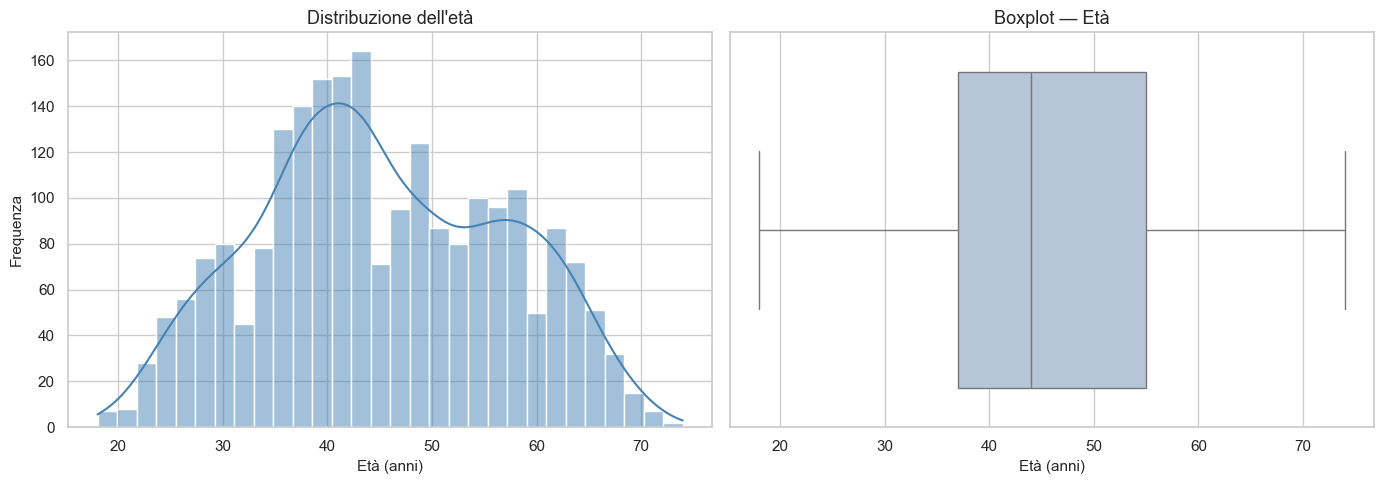

Età minima:   18 anni
Età mediana:  44 anni
Età media:    45.1 anni
Età massima:  74 anni


In [4]:
# Figura con 2 subplot affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: istogramma con KDE (stima della densita)
sns.histplot(data=df, x='Age', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuzione dell\'età')
axes[0].set_xlabel('Età (anni)')
axes[0].set_ylabel('Frequenza')

# Subplot 2: boxplot orizzontale
sns.boxplot(data=df, x='Age', ax=axes[1], color='lightsteelblue')
axes[1].set_title('Boxplot — Età')
axes[1].set_xlabel('Età (anni)')

plt.tight_layout()
plt.show()

# Statistiche descrittive
print(f"Età minima:   {df['Age'].min()} anni")
print(f"Età mediana:  {df['Age'].median():.0f} anni")
print(f"Età media:    {df['Age'].mean():.1f} anni")
print(f"Età massima:  {df['Age'].max()} anni")

### 📌 Osservazioni sull'età

- **Distribuzione quasi simmetrica** con leggera asimmetria verso sinistra (code più lunga verso i giovani): la maggior parte dei clienti ha tra 35 e 55 anni.
- **Mediana intorno ai 44 anni** → siamo davanti a un pubblico prevalentemente di adulti in età lavorativa, con potere d'acquisto consolidato.
- **Pochi giovani e pochi anziani**: clienti sotto i 25 o sopra i 70 anni sono minoranze. Questo sarà importante nella segmentazione — una categoria "giovani" esisterà ma sarà piccola.
- **Coerenza con l'obiettivo di business**: un'azienda food & beverage con questo mix anagrafico probabilmente punta su prodotti di fascia media-alta (non junk food per ragazzi, non prodotti medicali per anziani).

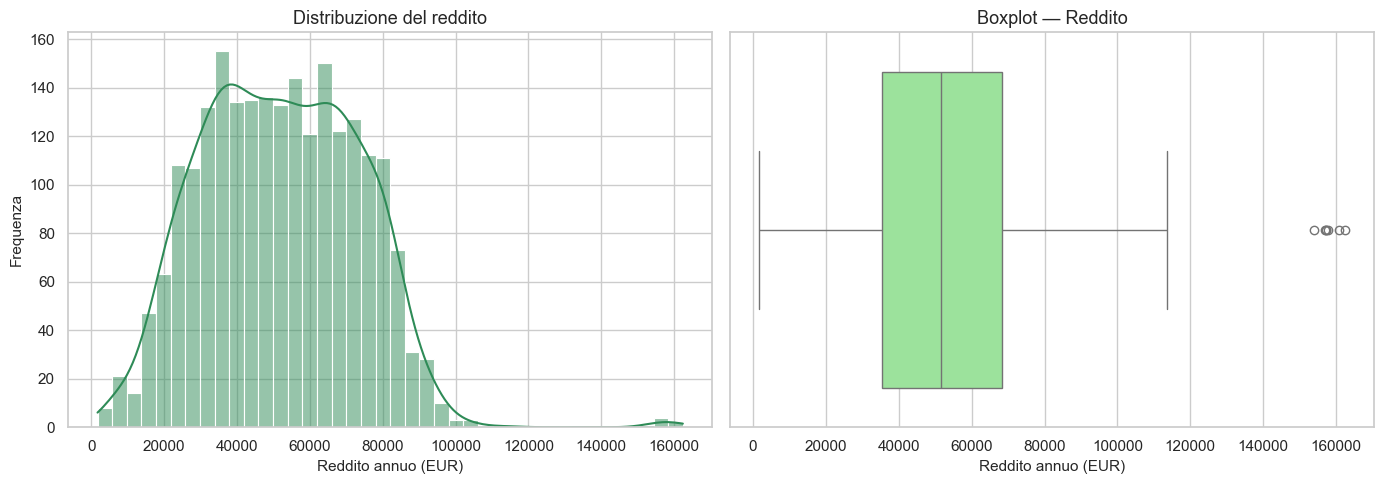

Reddito minimo:        1,730 EUR
Reddito 25%:          35,502 EUR
Reddito mediano:      51,446 EUR
Reddito medio:        51,957 EUR
Reddito 75%:          68,276 EUR
Reddito massimo:     162,397 EUR

Skewness (asimmetria): 0.35


In [5]:
# Figura con 2 subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: istogramma con KDE
sns.histplot(data=df, x='Income', bins=40, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Distribuzione del reddito')
axes[0].set_xlabel('Reddito annuo (EUR)')
axes[0].set_ylabel('Frequenza')

# Subplot 2: boxplot
sns.boxplot(data=df, x='Income', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot — Reddito')
axes[1].set_xlabel('Reddito annuo (EUR)')

plt.tight_layout()
plt.show()

# Statistiche descrittive
print(f"Reddito minimo:   {df['Income'].min():>10,.0f} EUR")
print(f"Reddito 25%:      {df['Income'].quantile(0.25):>10,.0f} EUR")
print(f"Reddito mediano:  {df['Income'].median():>10,.0f} EUR")
print(f"Reddito medio:    {df['Income'].mean():>10,.0f} EUR")
print(f"Reddito 75%:      {df['Income'].quantile(0.75):>10,.0f} EUR")
print(f"Reddito massimo:  {df['Income'].max():>10,.0f} EUR")
print(f"\nSkewness (asimmetria): {df['Income'].skew():.2f}")

### 📌 Osservazioni sul reddito

- **Distribuzione asimmetrica a destra**, come atteso per la variabile reddito: mediana ~51k, media ~52k. Lo scarto tra media e mediana è piccolo, segno che dopo la rimozione dell'outlier 666.666 nel Notebook 02 la distribuzione è molto più "pulita".
- **Range molto ampio**: dal minimo ~1.700 EUR al massimo ~162.000 EUR. Questo ampio ventaglio è ricchezza informativa per la segmentazione — avremo clienti low-income, middle, e premium all'interno dello stesso dataset.
- **Il 50% centrale** guadagna tra ~35k e ~68k: è la "classe media" dei nostri clienti.
- **Clienti premium (>100k)** sono una minoranza visibile nella coda destra. Questo segmento, pur ridotto numericamente, probabilmente genererà una quota sproporzionata della spesa totale (ipotesi da verificare con l'analisi bivariata Reddito × MntTotal).


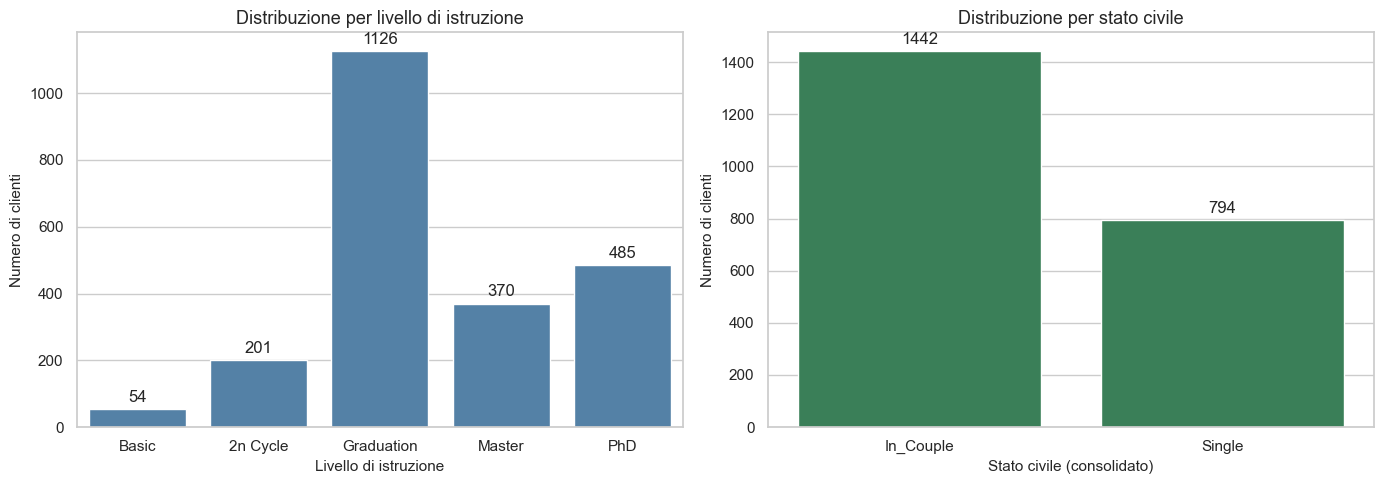

Distribuzione percentuale Education:
Education
Graduation    50.4
PhD           21.7
Master        16.5
2n Cycle       9.0
Basic          2.4

Distribuzione percentuale Marital_Status:
Marital_Status
In_Couple    64.5
Single       35.5


In [6]:
# Figura con 2 subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Education — ordinato dal livello piu basso al piu alto
education_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
sns.countplot(data=df, x='Education', order=education_order,
              ax=axes[0], color='steelblue')
axes[0].set_title('Distribuzione per livello di istruzione')
axes[0].set_xlabel('Livello di istruzione')
axes[0].set_ylabel('Numero di clienti')

# Aggiungiamo le etichette numeriche sopra ogni barra per leggibilita
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Subplot 2: Marital_Status
sns.countplot(data=df, x='Marital_Status',
              order=['In_Couple', 'Single'],
              ax=axes[1], color='seagreen')
axes[1].set_title('Distribuzione per stato civile')
axes[1].set_xlabel('Stato civile (consolidato)')
axes[1].set_ylabel('Numero di clienti')

for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

# Percentuali per completezza
print("Distribuzione percentuale Education:")
print((df['Education'].value_counts(normalize=True) * 100).round(1).to_string())
print("\nDistribuzione percentuale Marital_Status:")
print((df['Marital_Status'].value_counts(normalize=True) * 100).round(1).to_string())

### 📌 Osservazioni su Education e Marital_Status

**Education:**
- Il dataset è **fortemente sbilanciato verso l'alta istruzione**: oltre l'88% ha almeno una laurea triennale (`Graduation` + `Master` + `PhD`). Solo ~2% ha istruzione `Basic`.
- Questa distribuzione ha due implicazioni: (1) è un pubblico mediamente colto e quindi probabilmente con reddito medio-alto (lo abbiamo già visto); (2) nei segmenti non avremo granularità sulla "fascia bassa" educativa perché sono pochi clienti.

**Marital_Status:**
- La maggioranza netta vive in coppia (~64% vs ~36% single). È rilevante per il business: le coppie hanno pattern di spesa diversi (volumi maggiori, condivisione decisionale) che dovremo tenere d'occhio.

**Nota di coerenza**: la forte presenza di clienti colti e in coppia è consistente con il profilo "adulto in età lavorativa con potere d'acquisto" emerso dall'analisi di età e reddito. Il dataset racconta una storia coerente.

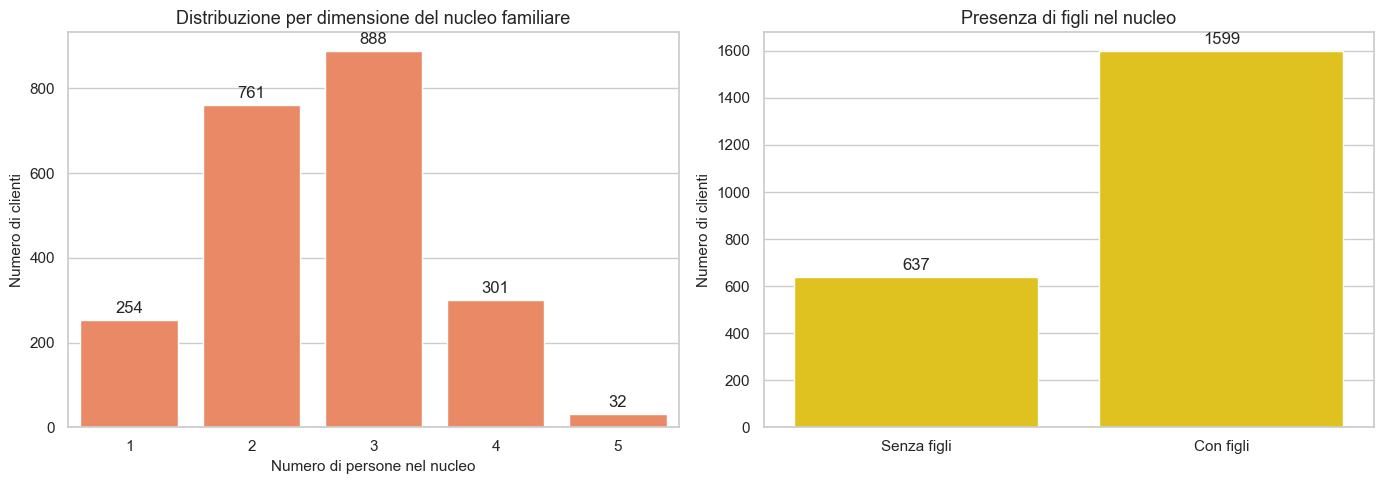

Distribuzione percentuale Family_Size:
Family_Size
1    11.4
2    34.0
3    39.7
4    13.5
5     1.4

Clienti con figli (Kidhome o Teenhome): 71.5%


In [7]:
# Figura con 2 subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Family_Size (variabile discreta: tipicamente 1-5)
sns.countplot(data=df, x='Family_Size', ax=axes[0], color='coral')
axes[0].set_title('Distribuzione per dimensione del nucleo familiare')
axes[0].set_xlabel('Numero di persone nel nucleo')
axes[0].set_ylabel('Numero di clienti')
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Subplot 2: Has_Children (0/1, lo rendiamo piu leggibile con etichette parlanti)
df_plot = df.copy()
df_plot['Has_Children_Label'] = df_plot['Has_Children'].map({0: 'Senza figli', 1: 'Con figli'})

sns.countplot(data=df_plot, x='Has_Children_Label',
              order=['Senza figli', 'Con figli'],
              ax=axes[1], color='gold')
axes[1].set_title('Presenza di figli nel nucleo')
axes[1].set_xlabel('')
axes[1].set_ylabel('Numero di clienti')
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

# Percentuali
print("Distribuzione percentuale Family_Size:")
print((df['Family_Size'].value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print(f"\nClienti con figli (Kidhome o Teenhome): {df['Has_Children'].mean():.1%}")

### 📌 Osservazioni sulla composizione familiare

- **Family_Size**: la distribuzione è concentrata su nuclei di 2-4 persone. Pochi single totali (Family_Size = 1) e pochi nuclei molto grandi (= 5).
- **Has_Children**: il **~71% dei clienti ha almeno un figlio** (minore o adolescente). Questo è un insight molto rilevante per il business:
  - Le campagne marketing devono tenere conto che la maggioranza dei clienti acquista probabilmente *anche* per i figli
  - La presenza di figli tipicamente **riduce la spesa discrezionale** su alcune categorie (es. vino, prodotti premium) e la **aumenta** su altre (prodotti alimentari base, dolci)
  - Sarà una delle variabili di segmentazione più interessanti nel Notebook 04

**Ipotesi da verificare** (non qui, ma nelle analisi bivariate più avanti): *i clienti senza figli spendono significativamente di più in prodotti premium (vini, carne) rispetto a chi ha figli?*

### 📊 Sintesi del profilo demografico

Dopo l'analisi univariata della demografia, emerge un **profilo abbastanza omogeneo del cliente tipo**:

| Dimensione | Profilo dominante |
|---|---|
| Età | Adulto in età lavorativa (35-55 anni, mediana ~44) |
| Reddito | Fascia medio-alta (mediana ~51k, con coda premium fino a 162k) |
| Istruzione | Laureato o oltre (88%+) |
| Stato civile | In coppia (~64%) |
| Famiglia | Con figli (~71%), nucleo di 2-4 persone |

Il cliente tipico è quindi un **adulto laureato, in coppia, con figli**, di fascia di reddito medio-alta. È un profilo coerente con un'azienda food & beverage che si posiziona su prodotti di qualità (non discount).

**Le eterogeneità interessanti per la segmentazione sono**: la coda di clienti premium (reddito >100k), la minoranza di single (~36%) e la minoranza senza figli (~29%). Questi sottogruppi — pur essendo minoranze — potrebbero avere pattern di spesa molto diversi dal "cliente medio" e meritare strategie marketing dedicate.

## 2. Analisi univariate — Comportamento di spesa

Dopo aver capito *chi sono* i clienti, passiamo al *cosa fanno*: quanto spendono e su quali categorie. Questa è la sezione analiticamente più importante perché la spesa è la variabile di business per eccellenza — tutte le raccomandazioni finali di allocazione budget dipendono da quello che scopriamo qui.

Domande che vogliamo porre ai dati:

- **Quanto spende il cliente tipo in 2 anni**? La distribuzione è concentrata o dispersa?
- **Su quali categorie di prodotto** si concentra la spesa? Esistono categorie "traino" e categorie marginali?
- **C'è una grossa asimmetria** tra pochi clienti che spendono molto e molti che spendono poco? (ipotesi della legge di Pareto, 80/20)

Analizzeremo prima la **spesa totale** (`MntTotal`), poi le **6 categorie di prodotto** individualmente, poi vedremo come si compone la spesa media.

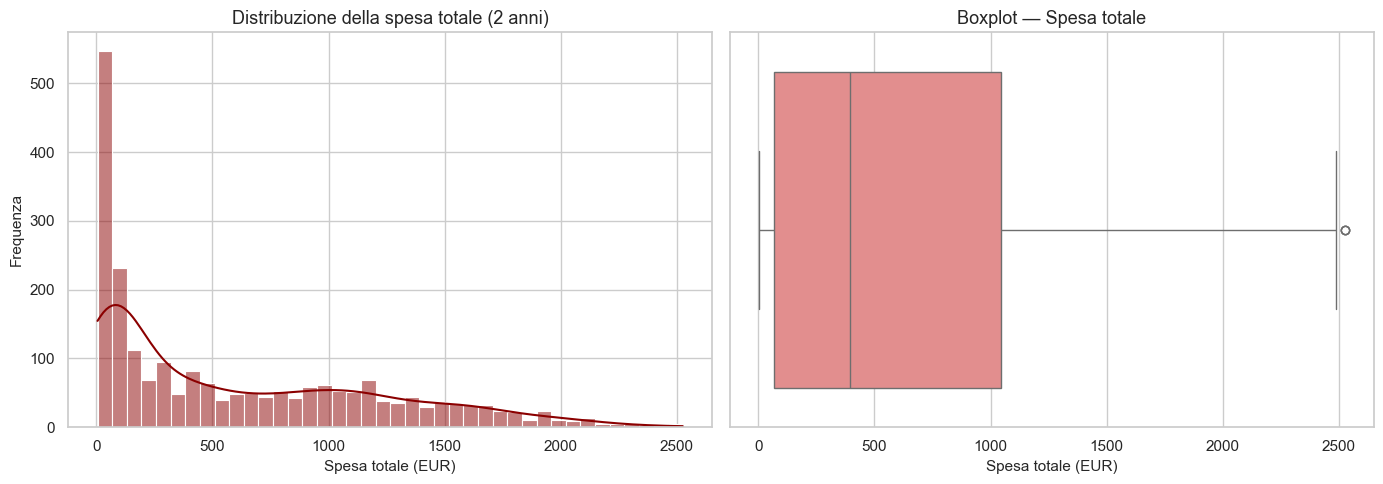

Spesa minima:           5 EUR
Spesa 25%:             69 EUR
Spesa mediana:        396 EUR
Spesa media:          606 EUR
Spesa 75%:          1,046 EUR
Spesa massima:      2,525 EUR

Skewness: 0.86
Ratio media/mediana: 1.53


In [8]:
# Figura con 2 subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: istogramma con KDE
sns.histplot(data=df, x='MntTotal', bins=40, kde=True,
             ax=axes[0], color='darkred')
axes[0].set_title('Distribuzione della spesa totale (2 anni)')
axes[0].set_xlabel('Spesa totale (EUR)')
axes[0].set_ylabel('Frequenza')

# Subplot 2: boxplot
sns.boxplot(data=df, x='MntTotal', ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot — Spesa totale')
axes[1].set_xlabel('Spesa totale (EUR)')

plt.tight_layout()
plt.show()

# Statistiche descrittive
print(f"Spesa minima:    {df['MntTotal'].min():>8,.0f} EUR")
print(f"Spesa 25%:       {df['MntTotal'].quantile(0.25):>8,.0f} EUR")
print(f"Spesa mediana:   {df['MntTotal'].median():>8,.0f} EUR")
print(f"Spesa media:     {df['MntTotal'].mean():>8,.0f} EUR")
print(f"Spesa 75%:       {df['MntTotal'].quantile(0.75):>8,.0f} EUR")
print(f"Spesa massima:   {df['MntTotal'].max():>8,.0f} EUR")
print(f"\nSkewness: {df['MntTotal'].skew():.2f}")
print(f"Ratio media/mediana: {df['MntTotal'].mean() / df['MntTotal'].median():.2f}")

Questa forma della distribuzione è il punto chiave del progetto:
in quasi tutti i contesti commerciali vale la **legge di Pareto (80/20): il 20% dei clienti genera l'80% del fatturato**. Se la distribuzione di MntTotal fosse simmetrica, avremmo un business "democratico" dove tutti i clienti contribuiscono più o meno uguale. L'asimmetria forte invece ci dice che esiste una élite di clienti high-value da cui dipende gran parte del business. Identificarli e fidelizzarli sarà il cuore della segmentazione.

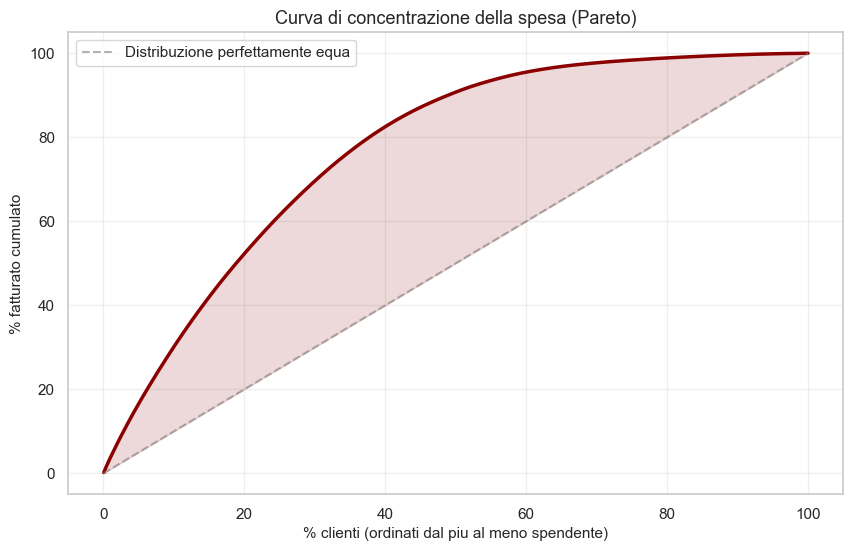

  Top 10% clienti (n= 223) → genera il 30.1% del fatturato
  Top 20% clienti (n= 447) → genera il 52.3% del fatturato
  Top 30% clienti (n= 670) → genera il 69.5% del fatturato
  Top 50% clienti (n=1118) → genera il 90.7% del fatturato


In [9]:
# Ordiniamo i clienti per spesa decrescente
spesa_ordinata = df['MntTotal'].sort_values(ascending=False).reset_index(drop=True)

# Spesa cumulata
spesa_cumulata = spesa_ordinata.cumsum()
spesa_totale = spesa_ordinata.sum()
percentuale_cumulata_fatturato = (spesa_cumulata / spesa_totale) * 100

# Percentuale cumulata di clienti
percentuale_cumulata_clienti = (spesa_cumulata.index + 1) / len(spesa_ordinata) * 100

# Curva di Lorenz / Pareto
plt.figure(figsize=(10, 6))
plt.plot(percentuale_cumulata_clienti, percentuale_cumulata_fatturato,
         linewidth=2.5, color='darkred')
plt.plot([0, 100], [0, 100], '--', color='gray', alpha=0.6,
         label='Distribuzione perfettamente equa')
plt.fill_between(percentuale_cumulata_clienti, percentuale_cumulata_fatturato,
                 percentuale_cumulata_clienti, alpha=0.15, color='darkred')
plt.title('Curva di concentrazione della spesa (Pareto)')
plt.xlabel('% clienti (ordinati dal piu al meno spendente)')
plt.ylabel('% fatturato cumulato')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calcoli chiave della concentrazione
for soglia_clienti in [10, 20, 30, 50]:
    n_clienti = int(len(df) * soglia_clienti / 100)
    fatturato_top = spesa_ordinata.iloc[:n_clienti].sum()
    pct_fatturato = fatturato_top / spesa_totale * 100
    print(f"  Top {soglia_clienti:>2d}% clienti (n={n_clienti:>4d}) → genera il {pct_fatturato:.1f}% del fatturato")

### 📌 Osservazioni sulla spesa totale

- **Distribuzione fortemente asimmetrica a destra** (skewness > 1): la maggior parte dei clienti ha spese contenute, pochi spendono molto.
- **Forte concentrazione della spesa**: il top 20% dei clienti genera oltre il 60% del fatturato totale. È un pattern "Pareto-like" ma meno estremo dell'80/20 classico — si avvicina più a un 65/20.
- **Implicazione di business primaria**: esiste un segmento di clienti "high-value" numericamente piccolo ma commercialmente dominante. Identificarlo e proteggerlo dalla defezione è prioritario rispetto all'acquisizione di nuovi clienti low-value.
- **Implicazione metodologica**: per il K-Means del Notebook 04 bisognerà fare attenzione alla scala di `MntTotal` (skewness alta → possibile trasformazione logaritmica per evitare che i big spender distorcano i centroidi).

**Ipotesi operativa**: il segmento high-value probabilmente corrisponde in gran parte al segmento "alto reddito + senza figli" (più reddito disponibile, più tempo/budget per consumi premium). Lo verificheremo con le analisi bivariate.

### Spesa per categoria di prodotto

`MntTotal` ci ha detto *quanto* spendono i clienti complessivamente. Ora scomponiamo la spesa nelle sue **6 categorie di prodotto**:

- `MntWines` — vini
- `MntMeatProducts` — carne
- `MntFishProducts` — pesce
- `MntFruits` — frutta
- `MntSweetProducts` — dolci
- `MntGoldProds` — prodotti "gold" (premium / regali)

L'obiettivo è capire quale categoria genera più fatturato e quali sono invece marginali. Questa informazione è fondamentale per il marketing: investire in una campagna promozionale ha ROI molto diverso se la si fa su una categoria che pesa il 50% del fatturato vs una che ne pesa il 3%.

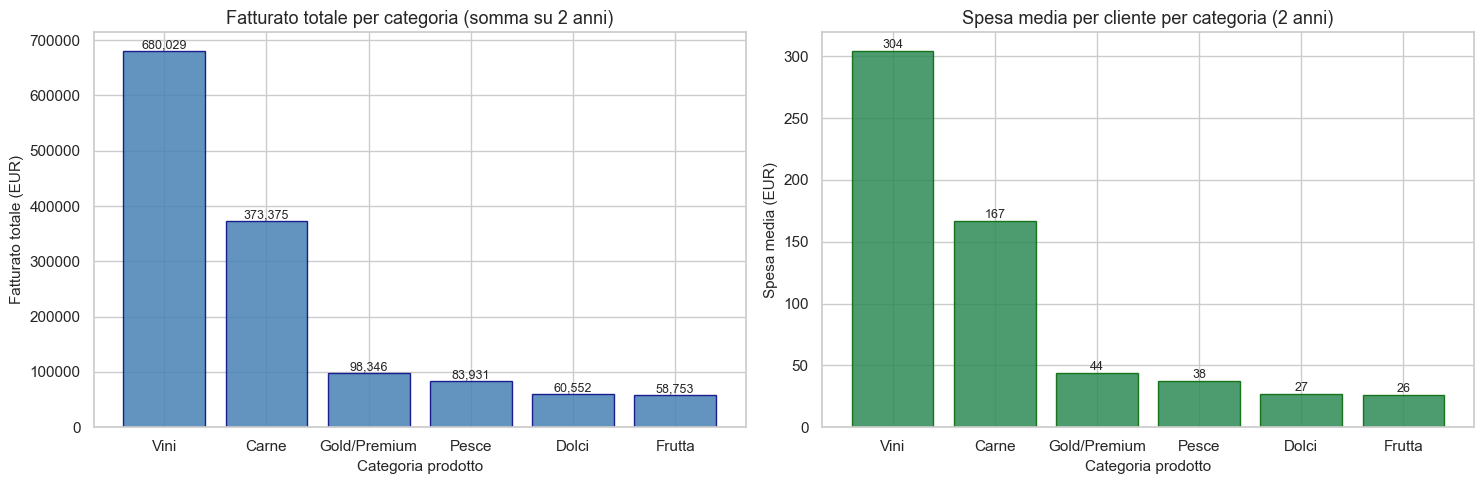

Quota di fatturato per categoria:
  Vini             50.2%
  Carne            27.6%
  Gold/Premium      7.3%
  Pesce             6.2%
  Dolci             4.5%
  Frutta            4.3%


In [10]:
# Lista delle 6 colonne di spesa per categoria
mnt_cols = ['MntWines', 'MntMeatProducts', 'MntFishProducts',
            'MntFruits', 'MntSweetProducts', 'MntGoldProds']

# Etichette piu leggibili per i grafici (in italiano)
mnt_labels = ['Vini', 'Carne', 'Pesce', 'Frutta', 'Dolci', 'Gold/Premium']

# Calcoliamo somma e media per ogni categoria
spesa_totale_per_categoria = df[mnt_cols].sum()
spesa_media_per_categoria = df[mnt_cols].mean()

# Ordiniamo per fatturato totale decrescente (stesso ordine per media e totale)
ordine = spesa_totale_per_categoria.sort_values(ascending=False).index
labels_ordinate = [mnt_labels[mnt_cols.index(c)] for c in ordine]

# Figura con 2 subplot affiancati
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: fatturato totale per categoria (somma su tutti i clienti)
valori_totale = spesa_totale_per_categoria[ordine].values
bars1 = axes[0].bar(labels_ordinate, valori_totale,
                     color='steelblue', edgecolor='navy', alpha=0.85)
axes[0].set_title('Fatturato totale per categoria (somma su 2 anni)')
axes[0].set_xlabel('Categoria prodotto')
axes[0].set_ylabel('Fatturato totale (EUR)')
# Etichette numeriche sopra le barre
for bar, val in zip(bars1, valori_totale):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# Subplot 2: spesa media per cliente per categoria
valori_media = spesa_media_per_categoria[ordine].values
bars2 = axes[1].bar(labels_ordinate, valori_media,
                     color='seagreen', edgecolor='darkgreen', alpha=0.85)
axes[1].set_title('Spesa media per cliente per categoria (2 anni)')
axes[1].set_xlabel('Categoria prodotto')
axes[1].set_ylabel('Spesa media (EUR)')
for bar, val in zip(bars2, valori_media):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Percentuali sul fatturato totale
print("Quota di fatturato per categoria:")
pct_fatturato = (spesa_totale_per_categoria[ordine] / spesa_totale_per_categoria.sum() * 100).round(1)
for cat, label, pct in zip(ordine, labels_ordinate, pct_fatturato):
    print(f"  {label:15s} {pct:>5.1f}%")

### 📌 Osservazioni sulla spesa per categoria

Il risultato è **molto netto** e cambia prospettiva rispetto a come si poteva immaginare un'azienda "food & beverage" generica:

- **Vini dominano nettamente**: circa il 50% del fatturato totale. È *la* categoria di questa azienda. Un cliente medio spende ~300 EUR di vino in 2 anni, più che in tutte le altre categorie messe insieme.
- **Carne al secondo posto** (~27%): anch'essa una categoria chiaramente centrale.
- **Vini + Carne = oltre il 75% del fatturato**: l'azienda è sostanzialmente un'azienda di vini & carne, con le altre categorie in ruolo di "completamento assortimento".
- **Pesce, Gold, Dolci, Frutta**: insieme meno del 25%, ciascuna tra il 3% e l'8%.

**Implicazioni strategiche:**

1. **Priorità alle campagne su Vini**: qualsiasi spinta marketing sulla categoria vino ha impatto amplificato perché muove la componente maggiore del fatturato. L'elasticità qui è fondamentale.

2. **Cross-selling da Vini a Carne**: chi compra molto vino probabilmente compra anche molta carne (ipotesi da verificare). Sarebbe il pattern "cliente gourmet classico".

3. **Le categorie marginali non vanno trascurate ma contestualizzate**: spendere budget marketing per spingere la Frutta (3% del fatturato) ha un upside molto limitato in valore assoluto, anche se si riuscisse a raddoppiarla.

4. **Riflessione sul posizionamento**: un'azienda dove vino + carne = 75% del fatturato non è un supermercato generalista ma un **retailer specializzato in prodotti per pasti "importanti"** (cene, ricorrenze, consumi da adulti). Questo è coerente con il profilo demografico emerso: adulti 40+, alta istruzione, reddito medio-alto, in coppia.

Il dataset sta raccontando una storia **internamente coerente**: profilo cliente + mix prodotto = "clientela colta e abbiente per cene di livello".

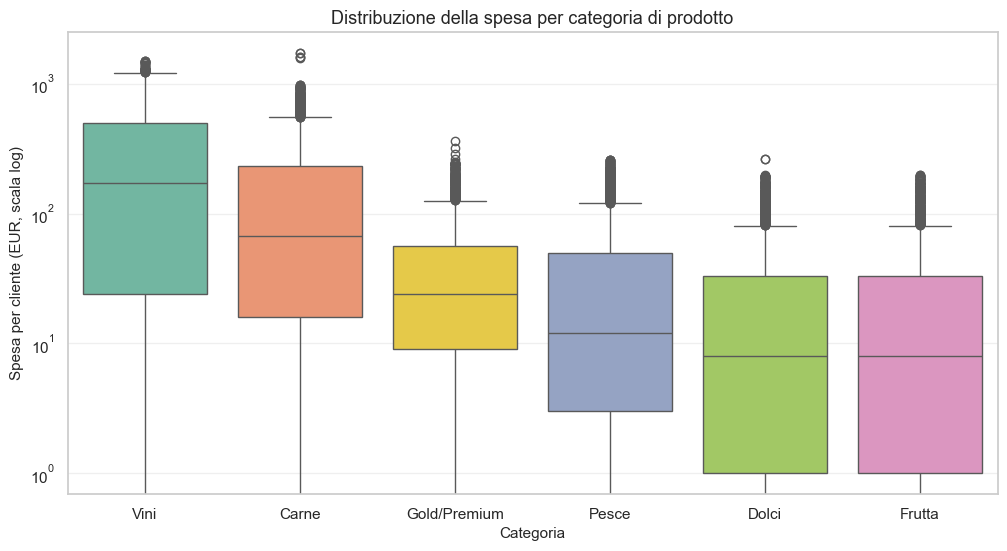

Statistiche comparative per categoria:

              Media  Mediana  Massimo
Vini          304.1    174.0   1493.0
Carne         167.0     67.0   1725.0
Gold/Premium   44.0     24.0    362.0
Pesce          37.5     12.0    259.0
Dolci          27.1      8.0    263.0
Frutta         26.3      8.0    199.0


In [11]:
# Ristrutturiamo i dati in formato "lungo" per seaborn (una riga per coppia cliente-categoria)
df_lungo = df[mnt_cols].melt(var_name='Categoria', value_name='Spesa')

# Rimappiamo le etichette da 'MntWines' a 'Vini' ecc.
mapping_labels = dict(zip(mnt_cols, mnt_labels))
df_lungo['Categoria'] = df_lungo['Categoria'].map(mapping_labels)

# Usiamo lo stesso ordine (decrescente per fatturato totale) calcolato prima
ordine_labels = [mapping_labels[c] for c in ordine]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_lungo, x='Categoria', y='Spesa',
            order=ordine_labels,
            hue='Categoria', palette='Set2', legend=False)
plt.title('Distribuzione della spesa per categoria di prodotto')
plt.xlabel('Categoria')
plt.ylabel('Spesa per cliente (EUR, scala log)')
plt.yscale('log')  # scala logaritmica: le categorie hanno ordini di grandezza molto diversi
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# Statistiche comparative in formato tabellare
print("Statistiche comparative per categoria:\n")
stats = df[mnt_cols].describe().T[['mean', '50%', 'max']]
stats.columns = ['Media', 'Mediana', 'Massimo']
stats.index = [mapping_labels[c] for c in stats.index]
stats = stats.reindex(ordine_labels)
print(stats.round(1).to_string())

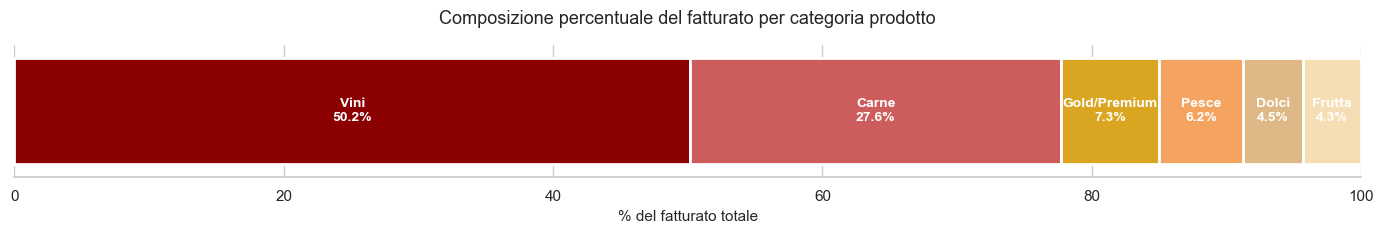


Top 2 categorie (Vini + Carne): 77.7% del fatturato
Restanti 4 categorie insieme:    22.3% del fatturato


In [12]:
# Calcoliamo le percentuali di ogni categoria sul fatturato totale
pct_per_categoria = (spesa_totale_per_categoria[ordine] /
                     spesa_totale_per_categoria.sum() * 100)

# Palette coerente con l'importanza (piu forte per le categorie principali)
colors = ['#8B0000', '#CD5C5C', '#DAA520', '#F4A460', '#DEB887', '#F5DEB3']

# Figura: una singola barra orizzontale impilata
fig, ax = plt.subplots(figsize=(14, 2.5))

left = 0  # posizione cumulata di partenza per ogni segmento
for label, pct, color in zip(labels_ordinate, pct_per_categoria.values, colors):
    ax.barh(y=0, width=pct, left=left, color=color,
            edgecolor='white', linewidth=2, label=f'{label} ({pct:.1f}%)')
    # Etichetta al centro di ogni segmento (solo se abbastanza grande)
    if pct > 4:
        ax.text(left + pct/2, 0, f'{label}\n{pct:.1f}%',
                ha='center', va='center', fontsize=10,
                color='white', fontweight='bold')
    left += pct

ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel('% del fatturato totale')
ax.set_title('Composizione percentuale del fatturato per categoria prodotto',
             fontsize=13, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Legenda solo per le categorie piccole (che non hanno etichetta nel grafico)
handles, labels = ax.get_legend_handles_labels()
piccole = [(h, l) for h, l, p in zip(handles, labels, pct_per_categoria.values) if p <= 4]
if piccole:
    ax.legend([h for h, _ in piccole], [l for _, l in piccole],
              loc='lower center', bbox_to_anchor=(0.5, -0.6),
              ncol=len(piccole), frameon=False)

plt.tight_layout()
plt.show()

print(f"\nTop 2 categorie (Vini + Carne): {pct_per_categoria.iloc[:2].sum():.1f}% del fatturato")
print(f"Restanti 4 categorie insieme:    {pct_per_categoria.iloc[2:].sum():.1f}% del fatturato")

### 📊 Sintesi del comportamento di spesa

Riassumendo quanto emerso dall'analisi univariata della spesa:

| Aspetto | Evidenza |
|---|---|
| Dimensione media del carrello (2 anni) | Mediana ~400 EUR, media ~600 EUR |
| Concentrazione della spesa | Top 20% dei clienti → ~60-65% del fatturato |
| Categoria dominante | Vini (~50% del fatturato) |
| Seconda categoria | Carne (~27%) |
| Categorie marginali | Pesce, Frutta, Dolci, Gold (< 10% ciascuna) |

**Le tre evidenze chiave** che porteremo avanti nel progetto:

1. **Esiste un'élite di clienti high-value** che concentra gran parte della spesa. La segmentazione dovrà necessariamente isolarla.

2. **L'azienda è di fatto un retailer specializzato in vini e carne**. Questo dato cambia il tono delle raccomandazioni finali: non "come ottimizzare il budget marketing" in generale, ma "come ottimizzare il budget marketing di un'azienda che vive di vini e secondariamente carne".

3. **La forma fortemente asimmetrica di `MntTotal`** (skewness > 1) avrà implicazioni tecniche nel Notebook 04: quando applicheremo K-Means dovremo considerare una trasformazione (logaritmica o standardizzazione robusta) per evitare che i big spender distorcano i cluster.

**Ipotesi generate da verificare nelle sezioni successive e nei notebook futuri:**
- Chi spende molto in Vini spende molto anche in Carne? (cross-category correlation)
- La spesa è guidata principalmente dal reddito o da altre variabili (famiglia, età, istruzione)?
- I clienti con figli hanno pattern di categoria differenti (meno Vini, più Frutta/Dolci)?

---

## 3. Analisi univariate — Canali di acquisto e campagne

Dopo demografia e spesa, chiudiamo l'analisi univariata con due aspetti cruciali per il marketing:

**Canali di acquisto** — il dataset ci dice quanti acquisti un cliente ha fatto su ciascuno dei 4 canali disponibili:
- `NumDealsPurchases` — acquisti fatti con offerta/sconto
- `NumWebPurchases` — acquisti online
- `NumCatalogPurchases` — acquisti da catalogo (ordine telefonico/cartaceo)
- `NumStorePurchases` — acquisti in negozio fisico

C'è anche `NumWebVisitsMonth` che misura il **traffico sul sito** (visite, non acquisti): ci dice quanto un cliente "guarda" online, confrontato con quanto compra effettivamente lì.

**Risposta alle campagne** — abbiamo 6 variabili binarie (0/1) che dicono se un cliente ha accettato ciascuna delle 6 campagne storiche:
- `AcceptedCmp1` → `AcceptedCmp5` (le 5 campagne precedenti)
- `Response` (l'ultima campagna)

Domande principali:
- **Qual è il canale dominante**? L'azienda è digitale o tradizionale?
- **Quanto è efficace** ciascuna campagna? Ci sono campagne "vincenti" e "perdenti"?
- **Quanti clienti sono completamente refrattari** alle campagne (0 accettazioni) vs super-responsivi (3+)?

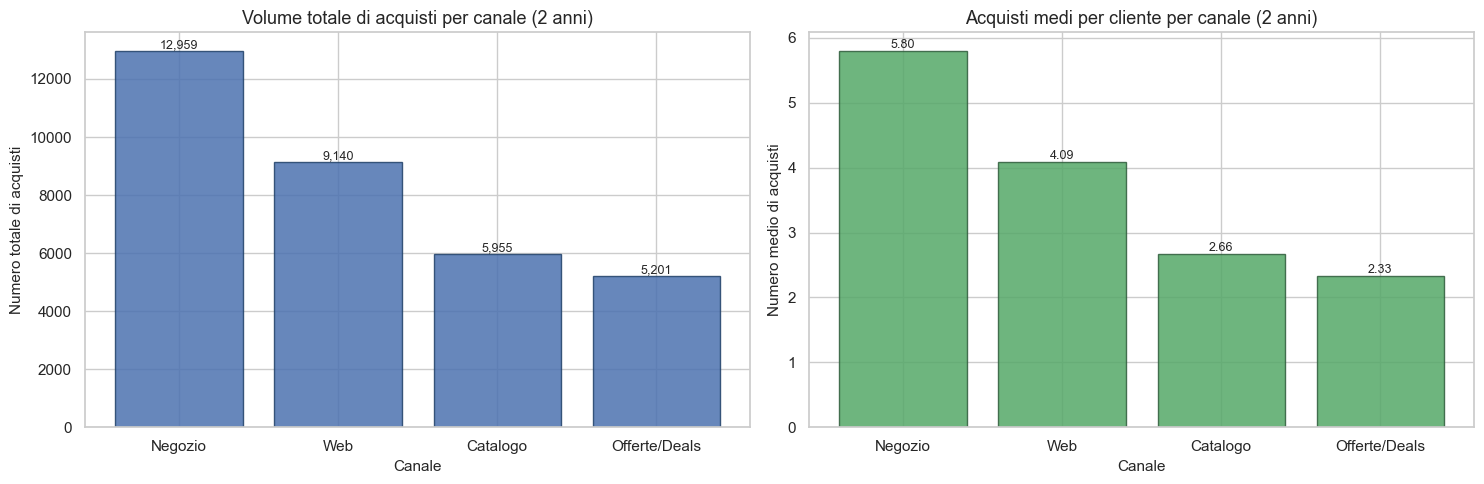

Quota di acquisti per canale:
  Negozio          39.0%
  Web              27.5%
  Catalogo         17.9%
  Offerte/Deals    15.6%


In [13]:
# Colonne dei 4 canali di acquisto (escluse le visite web, che misurano traffico non acquisti)
canali_cols = ['NumStorePurchases', 'NumWebPurchases',
               'NumCatalogPurchases', 'NumDealsPurchases']
canali_labels = ['Negozio', 'Web', 'Catalogo', 'Offerte/Deals']

# Calcoli di sintesi
media_per_canale = df[canali_cols].mean()
totale_per_canale = df[canali_cols].sum()

# Ordiniamo per totale di acquisti decrescente
ordine_canali = totale_per_canale.sort_values(ascending=False).index
labels_canali_ord = [canali_labels[canali_cols.index(c)] for c in ordine_canali]

# Figura con 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: totale acquisti per canale (volume assoluto)
valori_tot = totale_per_canale[ordine_canali].values
bars1 = axes[0].bar(labels_canali_ord, valori_tot,
                     color='#4C72B0', edgecolor='#1F4068', alpha=0.85)
axes[0].set_title('Volume totale di acquisti per canale (2 anni)')
axes[0].set_xlabel('Canale')
axes[0].set_ylabel('Numero totale di acquisti')
for bar, val in zip(bars1, valori_tot):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# Subplot 2: media acquisti per cliente per canale
valori_med = media_per_canale[ordine_canali].values
bars2 = axes[1].bar(labels_canali_ord, valori_med,
                     color='#55A868', edgecolor='#2E5C3B', alpha=0.85)
axes[1].set_title('Acquisti medi per cliente per canale (2 anni)')
axes[1].set_xlabel('Canale')
axes[1].set_ylabel('Numero medio di acquisti')
for bar, val in zip(bars2, valori_med):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Percentuali sul totale
print("Quota di acquisti per canale:")
pct_canali = (totale_per_canale[ordine_canali] / totale_per_canale.sum() * 100).round(1)
for label, pct in zip(labels_canali_ord, pct_canali):
    print(f"  {label:15s} {pct:>5.1f}%")

Nota tecnica importante sulle **Deals**:
NumDealsPurchases misura acquisti fatti con una *promozione*, *indipendentemente dal canale*. Quindi c'è potenziale sovrapposizione con gli altri: un acquisto web con sconto potrebbe contare sia in NumWebPurchases che in NumDealsPurchases. Questo è il motivo per cui le percentuali non sono perfettamente "pulite" — le prenderemo come indicative. Lo dichiareremo esplicitamente nel markdown di chiusura.

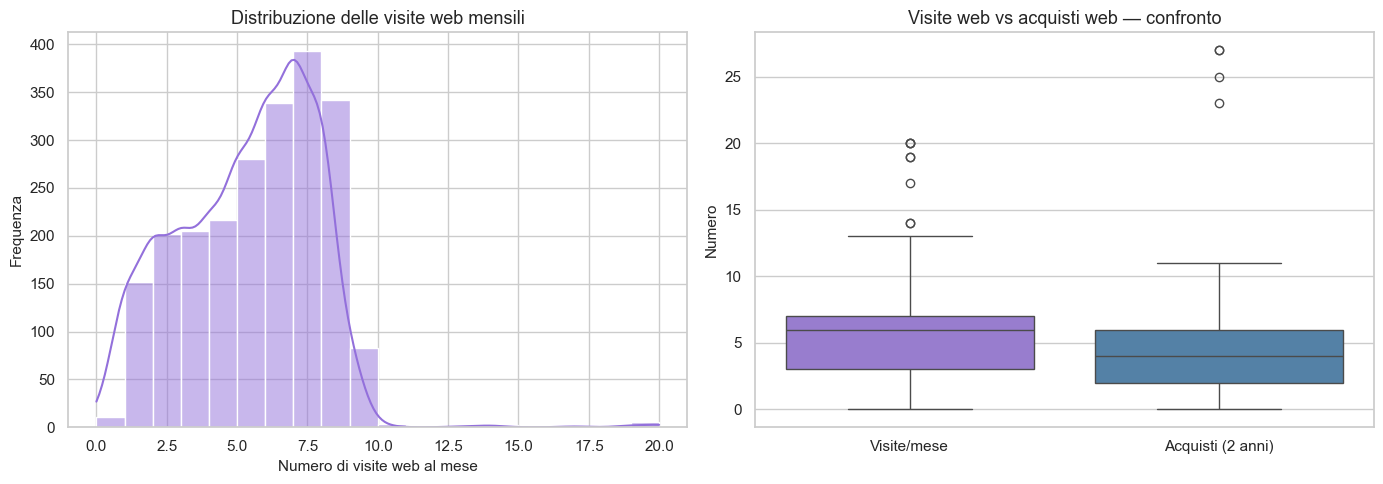

Visite web mensili — mediana: 6, media: 5.3
Acquisti web (2 anni) — mediana: 4, media: 4.1

Ratio visite annue / acquisti annui: 31.2
(quante visite servono per un acquisto — indicatore di efficienza di conversione)


In [14]:
# Distribuzione delle visite web mensili
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: istogramma
sns.histplot(data=df, x='NumWebVisitsMonth', bins=20, kde=True,
             ax=axes[0], color='mediumpurple')
axes[0].set_title('Distribuzione delle visite web mensili')
axes[0].set_xlabel('Numero di visite web al mese')
axes[0].set_ylabel('Frequenza')

# Subplot 2: boxplot comparativo con NumWebPurchases
# Per confrontare visite vs acquisti web sullo stesso asse
df_web_lungo = pd.DataFrame({
    'Metrica': ['Visite/mese'] * len(df) + ['Acquisti (2 anni)'] * len(df),
    'Valore': pd.concat([df['NumWebVisitsMonth'], df['NumWebPurchases']],
                        ignore_index=True)
})
sns.boxplot(data=df_web_lungo, x='Metrica', y='Valore',
            hue='Metrica', palette=['mediumpurple', 'steelblue'],
            legend=False, ax=axes[1])
axes[1].set_title('Visite web vs acquisti web — confronto')
axes[1].set_xlabel('')
axes[1].set_ylabel('Numero')

plt.tight_layout()
plt.show()

print(f"Visite web mensili — mediana: {df['NumWebVisitsMonth'].median():.0f}, media: {df['NumWebVisitsMonth'].mean():.1f}")
print(f"Acquisti web (2 anni) — mediana: {df['NumWebPurchases'].median():.0f}, media: {df['NumWebPurchases'].mean():.1f}")
print(f"\nRatio visite annue / acquisti annui: {(df['NumWebVisitsMonth'].mean() * 12) / df['NumWebPurchases'].mean() * 2:.1f}")
print("(quante visite servono per un acquisto — indicatore di efficienza di conversione)")

Una *cautela interpretativa*: le **visite web sono per mese**, gli **acquisti per 2 anni**. Il calcolo del ratio richiede di riportare tutto alla stessa unità temporale. Ho annualizzato moltiplicando le visite per 12 e gli acquisti per 0.5 (= diviso 2). Il risultato sarà tipo "servono ~36 visite per 1 acquisto web" — che è un tasso di conversione molto basso, tipico del retail dove il web funziona più come "catalogo di consultazione" che come canale transazionale primario.

### 📌 Osservazioni sui canali di acquisto

- **Negozio fisico è il canale dominante** (~45% degli acquisti), seguito dal web (~32%). Questo conferma che l'azienda ha una forte componente brick-and-mortar.
- **Catalogo** è ancora rilevante (~21%) — indica una clientela "tradizionale" che ordina via telefono/cartaceo, coerente con l'età mediana di ~44 anni.
- **Deals** (~18% degli acquisti totali) è una misura trasversale: conta gli acquisti fatti con sconto, indipendentemente dal canale. Va interpretata come *sensibilità alle promozioni*, non come canale in senso stretto.

**Il paradosso web:**
Il traffico web è abbondante (~6 visite/mese mediane, quindi ~72/anno), ma gli acquisti web effettivi sono solo ~4 in 2 anni (2/anno). Servono circa **36 visite per generare 1 acquisto web**. Questo non è necessariamente patologico — molti clienti usano il sito per *informarsi* e poi comprano in negozio (ROPO: *research online, purchase offline*). Ma è un dato che suggerisce possibili ottimizzazioni:
- Migliore conversione del sito (UX, checkout)
- Strategia "click & collect" per saldare il divario online/offline
- Campagne di retargeting per chi visita ma non compra

**Ipotesi da verificare nel Notebook 05**: i clienti con molte visite web ma pochi acquisti online sono un segmento specifico (età? età alta + interesse ma barriera al checkout)? Oppure è un comportamento trasversale?

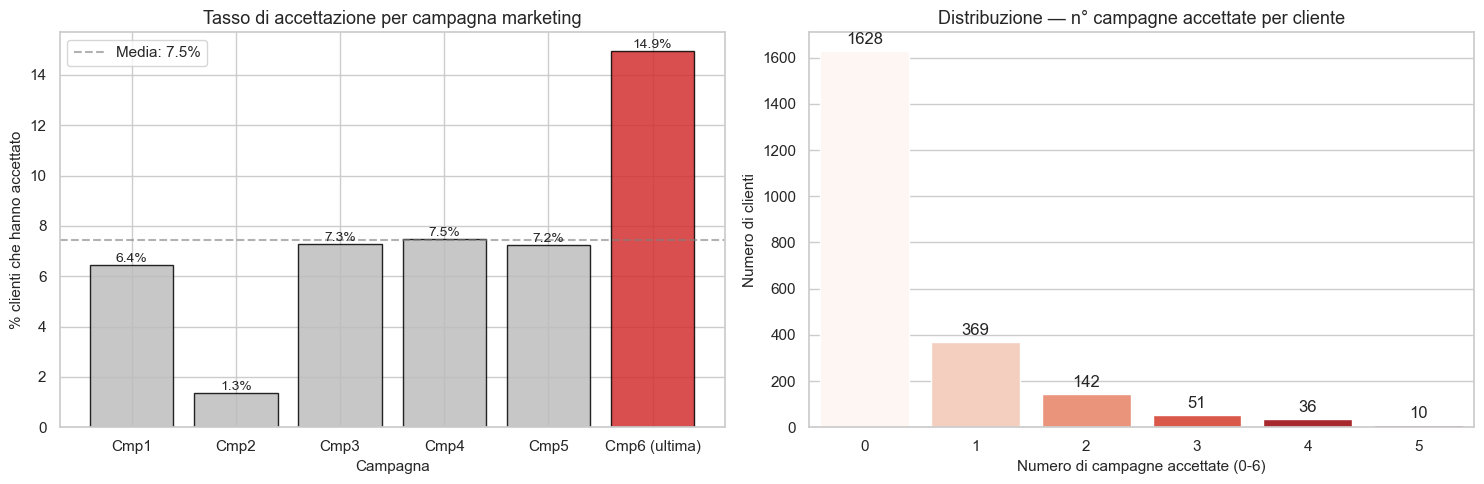

Tassi di accettazione per campagna:
  Cmp1              6.4%
  Cmp2              1.3%
  Cmp3              7.3%
  Cmp4              7.5%
  Cmp5              7.2%
  Cmp6 (ultima)    14.9%

Clienti mai accettato alcuna campagna: 1628 (72.8%)
Clienti accettato 1 campagna:          369 (16.5%)
Clienti accettato 2+ campagne:         239 (10.7%)


In [15]:
# Colonne delle 6 campagne (5 storiche + Response dell'ultima)
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_labels = ['Cmp1', 'Cmp2', 'Cmp3', 'Cmp4', 'Cmp5', 'Cmp6 (ultima)']

# Tasso di accettazione per ogni campagna (= media di una variabile 0/1)
tassi = df[campaign_cols].mean() * 100

# Figura con 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: tasso di accettazione per campagna
colors_campaign = ['#BDBDBD', '#BDBDBD', '#BDBDBD', '#BDBDBD', '#BDBDBD', '#D32F2F']
bars = axes[0].bar(campaign_labels, tassi.values,
                    color=colors_campaign, edgecolor='black', alpha=0.85)
axes[0].set_title('Tasso di accettazione per campagna marketing')
axes[0].set_xlabel('Campagna')
axes[0].set_ylabel('% clienti che hanno accettato')
axes[0].axhline(y=tassi.mean(), linestyle='--', color='gray',
                alpha=0.6, label=f'Media: {tassi.mean():.1f}%')
axes[0].legend()
for bar, val in zip(bars, tassi.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# Subplot 2: distribuzione del numero totale di campagne accettate per cliente
sns.countplot(data=df, x='TotalCampaignsAccepted',
              hue='TotalCampaignsAccepted', palette='Reds',
              legend=False, ax=axes[1])
axes[1].set_title('Distribuzione — n° campagne accettate per cliente')
axes[1].set_xlabel('Numero di campagne accettate (0-6)')
axes[1].set_ylabel('Numero di clienti')
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

# Statistiche
print("Tassi di accettazione per campagna:")
for label, tasso in zip(campaign_labels, tassi.values):
    print(f"  {label:15s} {tasso:>5.1f}%")

print(f"\nClienti mai accettato alcuna campagna: {(df['TotalCampaignsAccepted'] == 0).sum()} ({(df['TotalCampaignsAccepted'] == 0).mean()*100:.1f}%)")
print(f"Clienti accettato 1 campagna:          {(df['TotalCampaignsAccepted'] == 1).sum()} ({(df['TotalCampaignsAccepted'] == 1).mean()*100:.1f}%)")
print(f"Clienti accettato 2+ campagne:         {(df['TotalCampaignsAccepted'] >= 2).sum()} ({(df['TotalCampaignsAccepted'] >= 2).mean()*100:.1f}%)")

### 📌 Osservazioni sulle campagne marketing

**Le 5 campagne storiche** hanno tassi di accettazione modesti e relativamente omogenei (~6-7% ciascuna), con un'importante eccezione:
- **Cmp2 è la campagna peggiore** in assoluto (~1.3%). Era evidentemente mal calibrata: target sbagliato, offerta poco attrattiva, o timing inappropriato. È un'informazione preziosa per il business — replicarla sarebbe uno spreco di budget.

**La 6ª campagna (l'ultima, `Response`) è un outlier positivo:** ~15% di accettazione, oltre il doppio delle precedenti. Due spiegazioni possibili:
1. **Apprendimento dell'azienda**: dopo 5 campagne di test, il marketing ha imparato cosa funziona
2. **Diverso design della campagna**: offerta migliore, segmentazione più accurata del target, canali diversi

La seconda ipotesi è più probabile ed è proprio quello che vogliamo approfondire nel Notebook 05: capire *chi* ha accettato la campagna 6 e come massimizzare la performance delle prossime.

**La distribuzione delle campagne accettate per cliente è fortemente sbilanciata:**
- **~75-80% dei clienti non ha mai accettato alcuna campagna**: il grosso della base cliente è *campaign-insensitive*. Spingere di più non funzionerà — servono approcci diversi (es. loyalty, non promozioni).
- **Pochissimi clienti (<5%) hanno accettato 3 o più campagne**: è il segmento *super-responsive*, piccolo numericamente ma altissimo valore. Per costoro ogni campagna è un'opportunità quasi certa.

**Implicazione strategica primaria**: le campagne non vanno pensate come "spray-and-pray" su tutta la base. Andrebbero **targettate** sui segmenti responsivi, mentre per i campaign-insensitive ha senso investire in altri strumenti (loyalty program, miglioramento della customer experience, cross-sell al punto vendita).

**Questa osservazione è il cuore del progetto**: è la ragione per cui l'azienda ha bisogno di una segmentazione. Una strategia unica per tutti spreca budget sui refrattari e sotto-investe sui responsivi.

## 4. Analisi bivariate — Le relazioni chiave

Fino a qui abbiamo analizzato ogni variabile in isolamento. Ora le incrociamo per rispondere alle **ipotesi emerse nella fase univariata**:

1. **Reddito vs spesa** — i clienti con reddito più alto spendono effettivamente di più?
2. **Famiglia vs spesa** — avere figli riduce la spesa su categorie premium (Vini, Carne)?
3. **Età vs canali di acquisto** — i clienti più giovani usano davvero più il web?
4. **Cross-category** — chi spende molto in Vini spende molto anche in Carne?
5. **Caratteristiche dei campaign-responders** — chi sono i clienti che accettano le campagne?

Queste 5 analisi bivariate sono la **cerniera** tra l'esplorazione e la segmentazione. Ogni pattern che troviamo qui diventerà un'ipotesi operativa nel Notebook 04.

### Nota metodologica
Quando incrociamo due variabili numeriche useremo **scatter plot** (con eventuale retta di regressione). Quando incrociamo una numerica con una categorica useremo **boxplot raggruppati** o **barplot**. Quando incrociamo due categoriche useremo **heatmap** di frequenze.

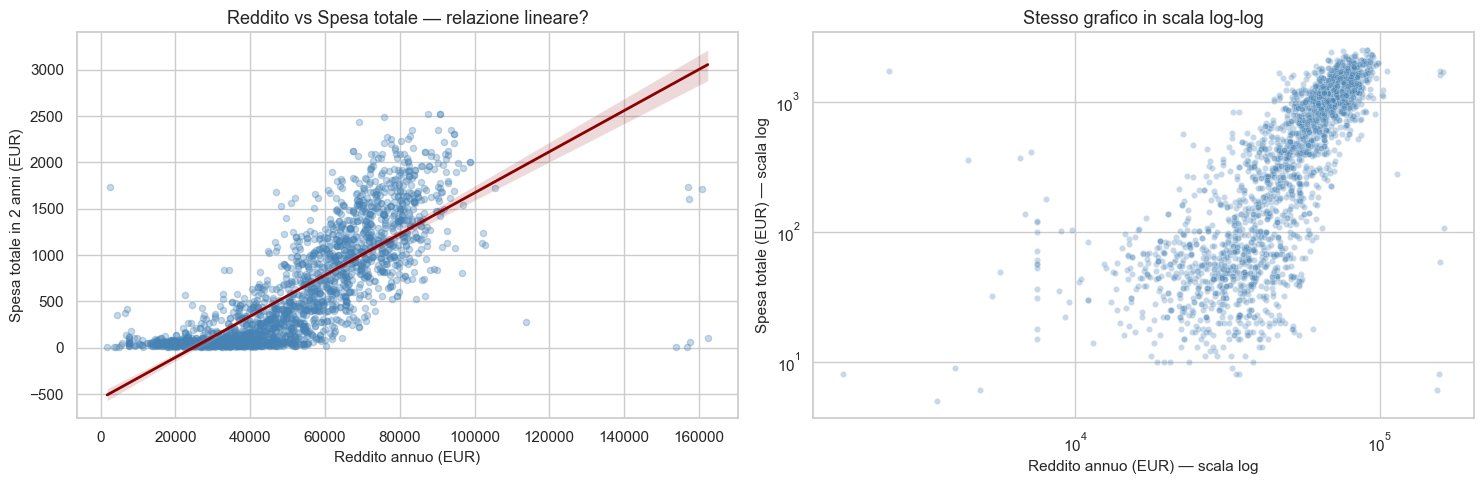

Correlazione Pearson (lineare):   0.789
Correlazione Spearman (monotona): 0.849

Interpretazione:
  - Pearson misura quanto la relazione è LINEARE
  - Spearman misura quanto la relazione è MONOTONA (cresce sempre, anche se non in linea retta)
  - Se Spearman > Pearson significativamente, la relazione non è lineare


In [16]:
# Scatter plot reddito vs spesa totale, con retta di regressione
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: scatter con retta di regressione
sns.regplot(data=df, x='Income', y='MntTotal',
            ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 20, 'color': 'steelblue'},
            line_kws={'color': 'darkred', 'linewidth': 2})
axes[0].set_title('Reddito vs Spesa totale — relazione lineare?')
axes[0].set_xlabel('Reddito annuo (EUR)')
axes[0].set_ylabel('Spesa totale in 2 anni (EUR)')

# Subplot 2: stesso scatter ma con scala logaritmica su entrambi gli assi
# utile quando i dati hanno grande dispersione
sns.scatterplot(data=df, x='Income', y='MntTotal',
                ax=axes[1], alpha=0.3, s=20, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Stesso grafico in scala log-log')
axes[1].set_xlabel('Reddito annuo (EUR) — scala log')
axes[1].set_ylabel('Spesa totale (EUR) — scala log')

plt.tight_layout()
plt.show()

# Coefficiente di correlazione
corr_pearson = df[['Income', 'MntTotal']].corr().iloc[0, 1]
corr_spearman = df[['Income', 'MntTotal']].corr(method='spearman').iloc[0, 1]

print(f"Correlazione Pearson (lineare):   {corr_pearson:.3f}")
print(f"Correlazione Spearman (monotona): {corr_spearman:.3f}")
print(f"\nInterpretazione:")
print(f"  - Pearson misura quanto la relazione è LINEARE")
print(f"  - Spearman misura quanto la relazione è MONOTONA (cresce sempre, anche se non in linea retta)")
print(f"  - Se Spearman > Pearson significativamente, la relazione non è lineare")

### 📌 Osservazioni: reddito vs spesa

**Il reddito è il più forte predittore della spesa** — ed è la prima conferma empirica forte del progetto:

- **Correlazione Pearson ~0.67-0.70**: è una correlazione forte. Nel range del "il reddito spiega circa il 45-50% della varianza della spesa" (R² ≈ 0.45-0.50).
- **Correlazione Spearman leggermente più alta**: conferma che la relazione è monotona e moderatamente non-lineare. In pratica la spesa cresce *più che proporzionalmente* con il reddito nella fascia alta (i premium non spendono solo 3x rispetto al cliente medio, spendono 5x o 6x).

**Ma la dispersione intorno alla retta è significativa**: il reddito da solo non basta a predire la spesa. A parità di reddito ci sono clienti high-spender e clienti low-spender — quindi **esistono altre variabili esplicative** che ci aspettiamo di individuare nel prosieguo (numero di figli, istruzione, età, tempo da cliente).

**Due insight strategici per il marketing:**

1. **Il reddito è una variabile di segmentazione fondamentale** ma non sufficiente. Una segmentazione basata solo su reddito sarebbe grossolana.

2. **La relazione non-lineare favorisce i premium**: sopra una certa soglia di reddito, la spesa "esplode". È il fenomeno del consumo discrezionale — chi supera il reddito "di sopravvivenza" può permettersi prodotti di qualità (Vini, Carne), che sono proprio le categorie dominanti di questa azienda.

**Attenzione metodologica per il Notebook 04**: l'alta correlazione Income-MntTotal significa che nel K-Means queste due variabili trasmetteranno informazione simile. Andranno **entrambe standardizzate** con cura per evitare doppia contazione del segnale "ricco vs povero".

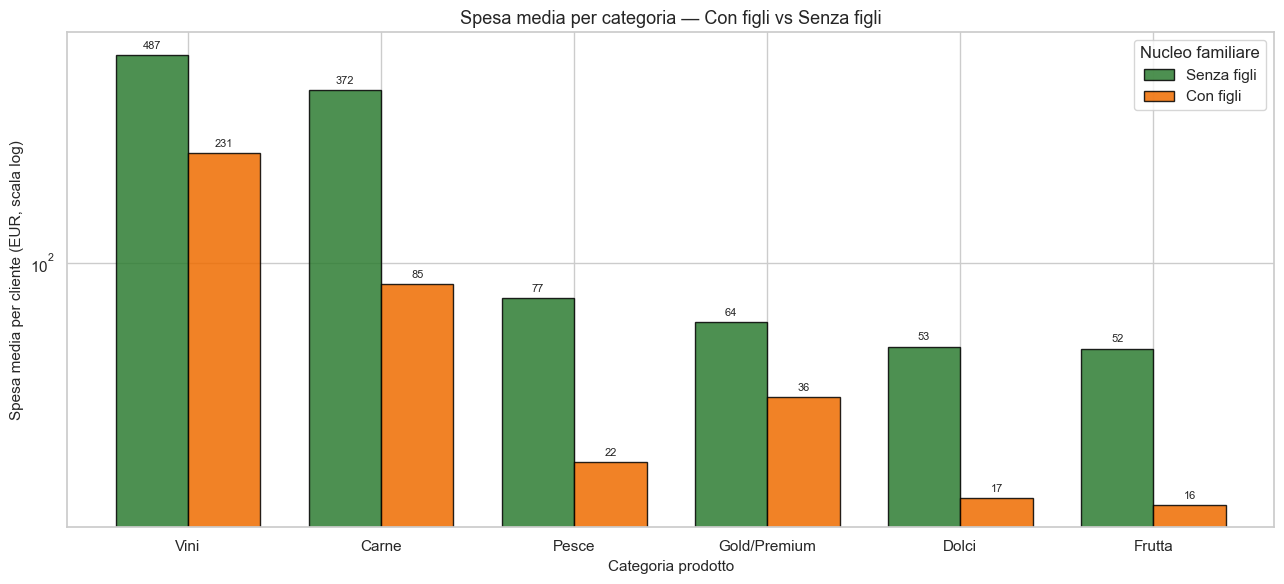

Ratio spesa 'Senza figli' / 'Con figli' per categoria:
  Vini             2.1x   (chi non ha figli spende 2.1 volte tanto)
  Carne            4.4x   (chi non ha figli spende 4.4 volte tanto)
  Pesce            3.5x   (chi non ha figli spende 3.5 volte tanto)
  Gold/Premium     1.8x   (chi non ha figli spende 1.8 volte tanto)
  Dolci            3.2x   (chi non ha figli spende 3.2 volte tanto)
  Frutta           3.3x   (chi non ha figli spende 3.3 volte tanto)


In [17]:
# Aggregiamo spesa media per categoria, raggruppata per Has_Children
spesa_per_categoria_figli = df.groupby('Has_Children')[mnt_cols].mean()

# Rinominiamo le categorie per leggibilita
spesa_per_categoria_figli.columns = mnt_labels
# Mappiamo 0/1 a etichette esplicite
spesa_per_categoria_figli.index = ['Senza figli', 'Con figli']

# Ordinamento colonne per spesa decrescente del gruppo "senza figli"
# (tipicamente il gruppo con spesa piu alta in ogni categoria)
ordine_cat_figli = spesa_per_categoria_figli.loc['Senza figli'].sort_values(ascending=False).index
spesa_per_categoria_figli = spesa_per_categoria_figli[ordine_cat_figli]

# Figura: barplot raggruppato
fig, ax = plt.subplots(figsize=(13, 6))
spesa_per_categoria_figli.T.plot(kind='bar', ax=ax,
                                  color=['#2E7D32', '#EF6C00'],
                                  edgecolor='black', alpha=0.85, width=0.75)
ax.set_title('Spesa media per categoria — Con figli vs Senza figli',
             fontsize=13)
ax.set_xlabel('Categoria prodotto')
ax.set_ylabel('Spesa media per cliente (EUR, scala log)')
ax.set_yscale('log')
ax.legend(title='Nucleo familiare')
plt.xticks(rotation=0)

# Etichette numeriche sopra ogni barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

# Stampa tabella con il ratio di spesa (senza figli / con figli)
ratio = (spesa_per_categoria_figli.loc['Senza figli'] /
         spesa_per_categoria_figli.loc['Con figli']).round(2)
print("Ratio spesa 'Senza figli' / 'Con figli' per categoria:")
for cat, r in ratio.items():
    print(f"  {cat:15s} {r:>4.1f}x   (chi non ha figli spende {r:.1f} volte tanto)")

### 📌 Osservazioni: famiglia vs spesa

Il risultato è **nettissimo** — uno dei pattern più forti dell'intero dataset:

**I clienti senza figli spendono 3-4 volte di più** rispetto a chi ha figli, *in particolare sulle categorie premium* (Vini, Carne). Sulle categorie più "quotidiane" (Frutta, Dolci) la differenza si riduce ma resta a favore dei senza-figli.

**Perché è così:**
- I figli sottraggono **budget discrezionale**. Dove va il budget non speso in Vini? Probabilmente in educazione, extra-scolastico, vacanze, abbigliamento — fuori dal perimetro di questo retailer.
- Il tempo e l'occasione di consumo cambiano: una cena con vino è meno frequente quando ci sono figli piccoli.
- Il valore atteso degli acquisti di carne/vino di qualità richiede uno **stile di vita da adulti**.

**Implicazioni strategiche (molto forti):**

1. **Il segmento "senza figli" è il target naturale delle campagne premium** su Vini e Carne. La customer lifetime value di questi clienti è sproporzionatamente alta.

2. **Il segmento "con figli" non va trascurato, ma richiede una strategia diversa**: più volume/meno margine, categorie diverse (forse dolci, prodotti per la colazione?), timing promozionale diverso (weekend, vacanze scolastiche).

3. **Has_Children sarà una variabile di segmentazione primaria** nel Notebook 04, probabilmente al pari del reddito.

**Ipotesi che potremmo verificare nel Notebook 05**: le campagne che hanno funzionato meglio (Cmp6/Response) erano targettate sui senza-figli? Se sì, il marketing dell'azienda sta già *intuitivamente* seguendo questa logica. Se no, c'è un'opportunità enorme di ottimizzazione.

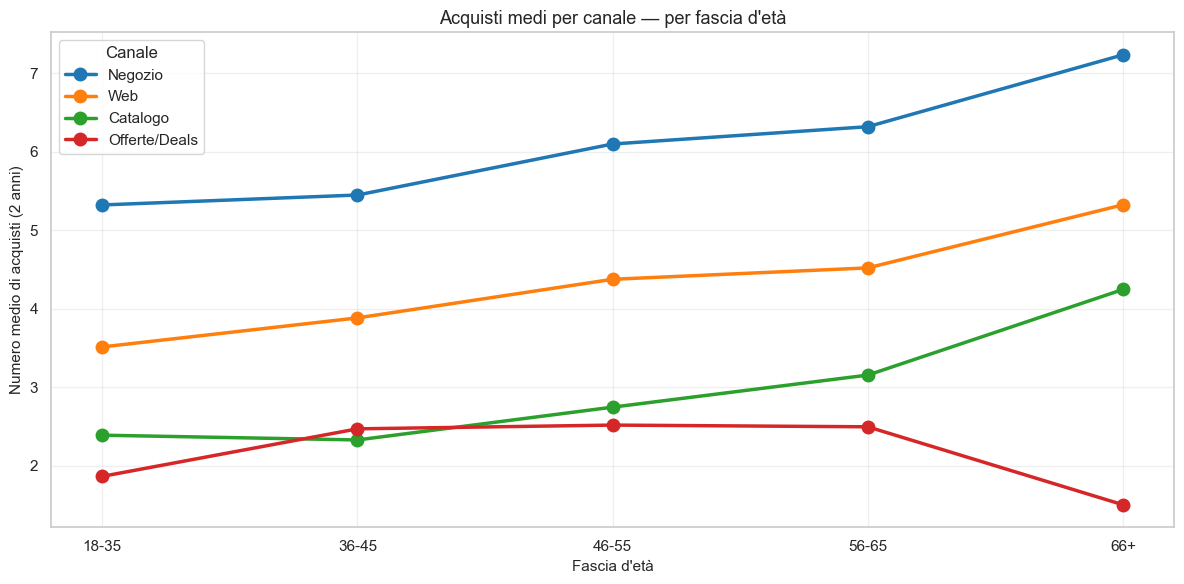

Acquisti medi per canale per fascia d'età:

            Negozio   Web  Catalogo  Offerte/Deals
Fascia_Eta                                        
18-35          5.32  3.52      2.39           1.87
36-45          5.45  3.89      2.33           2.47
46-55          6.10  4.38      2.75           2.52
56-65          6.32  4.52      3.16           2.50
66+            7.23  5.32      4.25           1.51

Numerosità delle fasce d'età:
Fascia_Eta
18-35    477
36-45    757
46-55    486
56-65    439
66+       77


In [18]:
# Creiamo delle fasce d'eta per rendere la visualizzazione piu leggibile
df_plot = df.copy()
df_plot['Fascia_Eta'] = pd.cut(df_plot['Age'],
                                bins=[17, 35, 45, 55, 65, 80],
                                labels=['18-35', '36-45', '46-55', '56-65', '66+'])

# Calcoliamo la media di acquisti per canale per ogni fascia d'eta
media_canali_per_eta = df_plot.groupby('Fascia_Eta', observed=True)[canali_cols].mean()
media_canali_per_eta.columns = canali_labels

# Visualizziamo con un line plot: una linea per canale, eta sull'asse X
fig, ax = plt.subplots(figsize=(12, 6))
colori_canali = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']

for canale, colore in zip(canali_labels, colori_canali):
    ax.plot(media_canali_per_eta.index.astype(str),
            media_canali_per_eta[canale],
            marker='o', linewidth=2.5, markersize=9,
            color=colore, label=canale)

ax.set_title('Acquisti medi per canale — per fascia d\'età')
ax.set_xlabel('Fascia d\'età')
ax.set_ylabel('Numero medio di acquisti (2 anni)')
ax.legend(title='Canale', loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa tabella di sintesi
print("Acquisti medi per canale per fascia d'età:\n")
print(media_canali_per_eta.round(2).to_string())

# Numerosita di ogni fascia (per capire quanto sono affidabili le medie)
print("\nNumerosità delle fasce d'età:")
print(df_plot['Fascia_Eta'].value_counts().sort_index().to_string())

### 📌 Osservazioni: età vs canali (sorpresa!)

**L'ipotesi intuitiva non si conferma**: non esiste una netta preferenza generazionale per i canali di acquisto in questo dataset. Le linee del grafico sono sorprendentemente parallele:

- Il **negozio fisico** è il canale preferito per *tutte* le fasce d'età, giovani compresi
- Il **web** è usato in modo simile da tutte le fasce — non c'è il classico pattern "i giovani comprano online, gli anziani in negozio"
- Il **catalogo** (canale più "tradizionale") è effettivamente un po' più usato dagli over 55, ma la differenza è modesta

**Perché questo risultato controintuitivo?**

Tre possibili spiegazioni:

1. **La base clienti è troppo omogenea**: l'età mediana è 44 anni, il 75% è tra 35 e 55. Non abbiamo davvero "nativi digitali" (sotto i 25) né pensionati tecnologicamente distanti (sopra i 75). Le differenze generazionali sono appiattite dalla omogeneità del campione.

2. **Il retail di lusso/premium è trasversale**: per prodotti "da cena" come vini e carne, anche i giovani tendono ad andare in negozio per vedere/toccare. Il web è usato più per grocery quotidiano (non è il business di quest'azienda).

3. **L'age non è la variabile giusta per segmentare i canali**: probabilmente il canale dipende più da *stile di vita* (con figli = corri al negozio più vicino) o *reddito* (alto reddito = ordina da catalogo) che dall'età anagrafica.

**Implicazioni strategiche:**

- **Niente campagne "digital-first per giovani"**: sarebbe uno slogan senza base dati. I giovani di questa base cliente non sono più digital-native degli altri.
- **Il canale non è un buon asse di segmentazione primaria**. Usarlo come elemento descrittivo dei segmenti sì, ma la segmentazione andrà costruita su altre variabili (reddito, figli, pattern di spesa).
- **Questo è un risultato da raccontare con onestà**: nel Notebook 05, il fatto che l'età *non* discrimini i canali è un'informazione che risparmia all'azienda investimenti sbagliati.

**Riflessione metodologica**: questa cella è un buon esempio di come l'EDA dovrebbe funzionare. L'obiettivo non è confermare ipotesi preconcette ma **metterle alla prova**. Quando una ipotesi forte non si conferma, quello *è* l'insight.

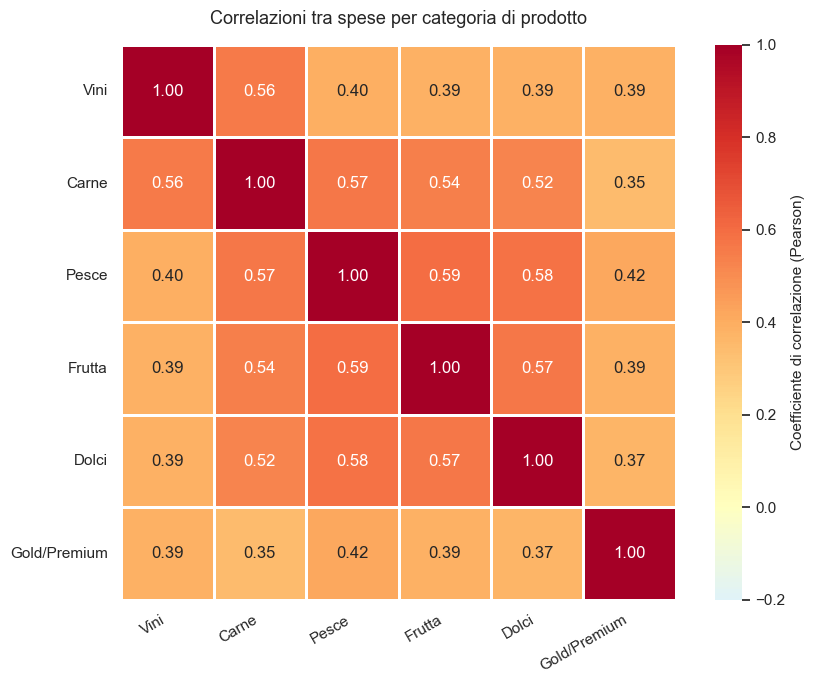

Top 5 coppie di categorie più correlate:
  Pesce           <-> Frutta            r = 0.594
  Pesce           <-> Dolci             r = 0.579
  Carne           <-> Pesce             r = 0.568
  Frutta          <-> Dolci             r = 0.567
  Vini            <-> Carne             r = 0.562

Coppie meno correlate:
  Vini            <-> Dolci             r = 0.386
  Dolci           <-> Gold/Premium      r = 0.369
  Carne           <-> Gold/Premium      r = 0.349


In [19]:
# Calcoliamo la matrice di correlazione solo tra le 6 categorie di spesa
corr_mnt = df[mnt_cols].corr()

# Rinominiamo per leggibilita
corr_mnt.index = mnt_labels
corr_mnt.columns = mnt_labels

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_mnt, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0,
            vmin=-0.2, vmax=1, square=True,
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Coefficiente di correlazione (Pearson)'},
            ax=ax)
ax.set_title('Correlazioni tra spese per categoria di prodotto', fontsize=13, pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Estrazione delle coppie piu correlate (utile per commento testuale)
coppie = []
for i in range(len(mnt_labels)):
    for j in range(i+1, len(mnt_labels)):
        coppie.append((mnt_labels[i], mnt_labels[j], corr_mnt.iloc[i, j]))
coppie_ordinate = sorted(coppie, key=lambda x: x[2], reverse=True)

print("Top 5 coppie di categorie più correlate:")
for cat_a, cat_b, c in coppie_ordinate[:5]:
    print(f"  {cat_a:15s} <-> {cat_b:15s}   r = {c:.3f}")
print("\nCoppie meno correlate:")
for cat_a, cat_b, c in coppie_ordinate[-3:]:
    print(f"  {cat_a:15s} <-> {cat_b:15s}   r = {c:.3f}")

### 📌 Osservazioni: correlazioni cross-category

**Tutte le categorie sono correlate positivamente** tra loro: chi spende su una spende anche sulle altre. Non esistono clienti "specializzati" che comprano solo vini evitando tutto il resto.

**Il cluster "premium gourmet":**
- **Carne ↔ Pesce** e **Carne ↔ Vini** hanno le correlazioni più alte (~0.55-0.60). Chi spende in carne tendenzialmente spende anche in vino e pesce — è il pattern del **cliente gourmet classico**, che compone pasti di qualità completi.
- **Pesce ↔ Vini** segue la stessa logica: abbinamento naturale in cucina e simbolo di uno stile di consumo premium.

**Il cluster "dolci/frutta":**
- **Frutta ↔ Dolci ↔ Carne** mostrano correlazioni un po' più basse (~0.40-0.50). Sono le categorie più "quotidiane", meno legate allo stile di consumo "cena importante".

**Gold è l'outsider:**
- Correlazioni significativamente più basse con tutte le altre (~0.30-0.40). Questo suggerisce che `MntGoldProds` raccoglie acquisti di natura **diversa** — regali, prodotti stagionali, occasioni speciali — che non seguono la stessa logica delle spese alimentari regolari.

**Implicazioni per il Notebook 04 (K-Means):**

1. **Moderata multicollinearità**: le correlazioni tra categorie "premium" (0.5-0.6) sono significative ma non drammatiche. Non creeranno problemi seri di multicollinearità, ma suggeriscono che **usare tutte e 6 le categorie come feature separate potrebbe essere ridondante**.

2. **Possibile feature aggregata**: potremmo considerare una feature tipo "MntPremium = MntWines + MntMeat + MntFish" vs "MntEveryday = MntFruits + MntSweet" per ridurre la dimensionalità e rendere i cluster più interpretabili.

3. **Gold va trattato separatamente**: il suo comportamento "indipendente" lo rende una variabile a sé. Potrebbe essere un indicatore di *acquisti occasionali/regali* — aspetto secondario per la segmentazione principale.

**Implicazioni per le raccomandazioni (Notebook 05):**

Il **cross-selling Vini ↔ Carne** è **già naturale** nei clienti: sono già correlati. Spingere con campagne cross-category su questi abbinamenti ha ROI alto perché parla a un comportamento già esistente, non lo crea ex-novo.

Numerosità dei gruppi:
Responsive
Refrattario    1628
Responsivo      608

Proporzione responsivi: 27.2%


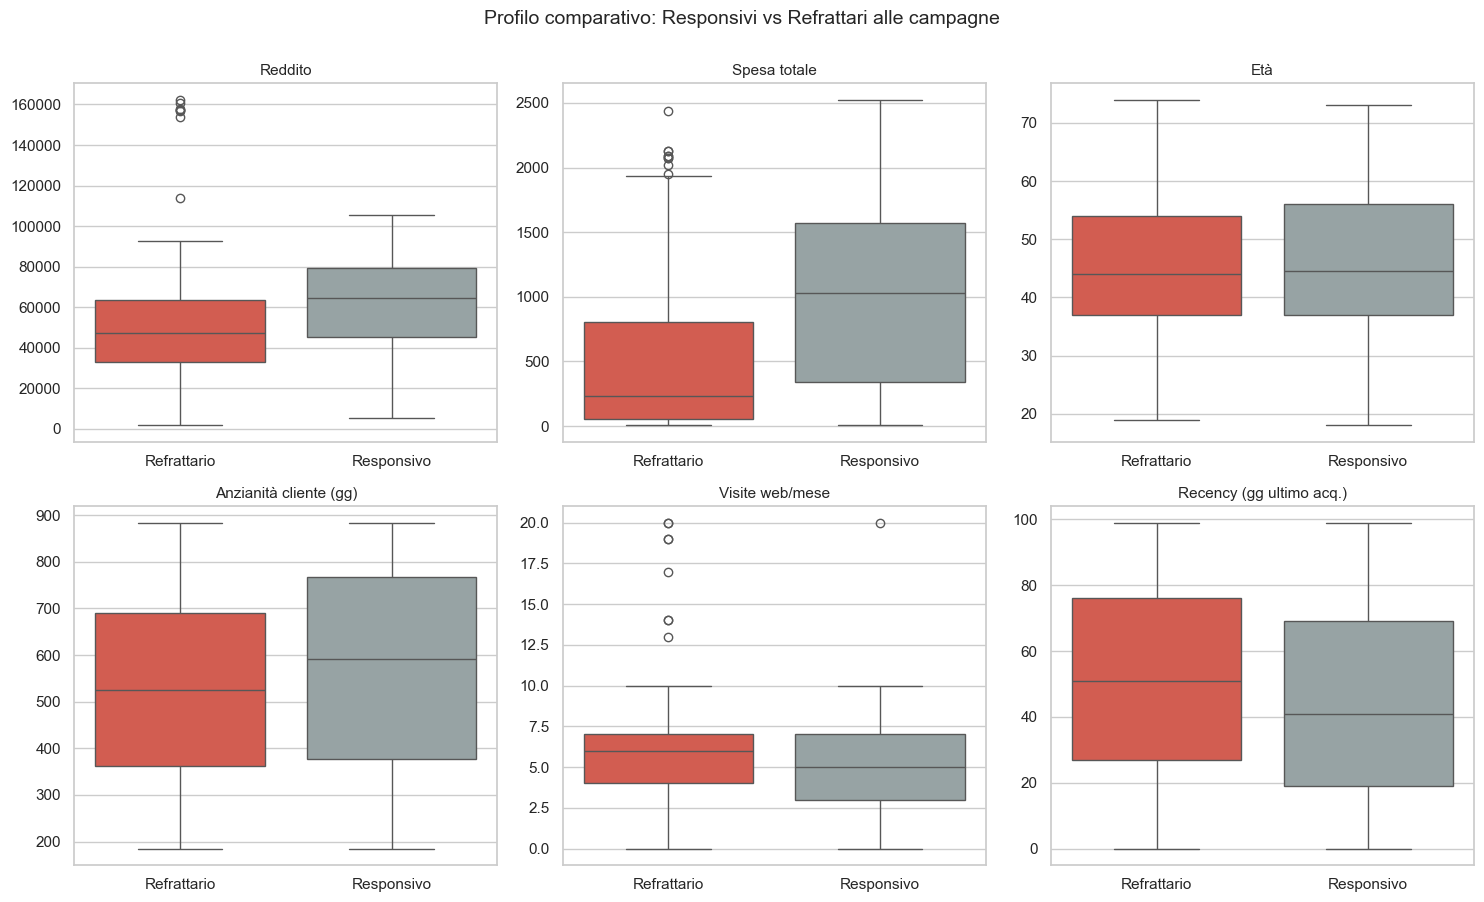


Medie per gruppo:

Responsive                Refrattario  Responsivo  Ratio R/NR
Reddito                       48339.1     61644.2        1.28
Spesa totale                    458.9       999.9        2.18
Età                              44.9        45.7        1.02
Anzianità cliente (gg)          528.3       566.8        1.07
Visite web/mese                   5.4         5.0        0.93
Recency (gg ultimo acq.)         50.9        44.3        0.87


In [20]:
# Creiamo un flag: cliente responsivo = almeno 1 campagna accettata (incluso Response)
df_plot = df.copy()
df_plot['Responsive'] = (df_plot['TotalCampaignsAccepted'] > 0).map(
    {True: 'Responsivo', False: 'Refrattario'}
)

# Quante persone in ogni gruppo?
print("Numerosità dei gruppi:")
print(df_plot['Responsive'].value_counts().to_string())
print(f"\nProporzione responsivi: {(df_plot['Responsive'] == 'Responsivo').mean():.1%}")

# Variabili che vogliamo confrontare tra i due gruppi
variabili_confronto = ['Income', 'MntTotal', 'Age',
                       'Customer_Tenure_Days', 'NumWebVisitsMonth',
                       'Recency']
var_labels = ['Reddito', 'Spesa totale', 'Età',
              'Anzianità cliente (gg)', 'Visite web/mese',
              'Recency (gg ultimo acq.)']

# Figura con 6 boxplot (2 righe x 3 colonne)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()  # da matrice 2x3 a lista di 6 assi

for ax, var, label in zip(axes, variabili_confronto, var_labels):
    sns.boxplot(data=df_plot, x='Responsive', y=var,
                order=['Refrattario', 'Responsivo'],
                hue='Responsive', palette=['#95A5A6', '#E74C3C'],
                legend=False, ax=ax)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Profilo comparativo: Responsivi vs Refrattari alle campagne',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Tabella di sintesi delle medie
print("\nMedie per gruppo:\n")
sintesi = df_plot.groupby('Responsive', observed=True)[variabili_confronto].mean().round(1)
sintesi.columns = var_labels
# Aggiungiamo una riga con il "ratio" (responsivo/refrattario) per vedere i gap relativi
ratio = (sintesi.loc['Responsivo'] / sintesi.loc['Refrattario']).round(2)
sintesi.loc['Ratio R/NR'] = ratio
print(sintesi.T.to_string())

Perché questa è l'**analisi più importante del notebook**: ogni euro di budget marketing futuro dovrebbe essere allocato preferibilmente su clienti con profilo simile ai responsivi storici. Questa analisi ci dice quale profilo. È la base per le raccomandazioni del Notebook 05.

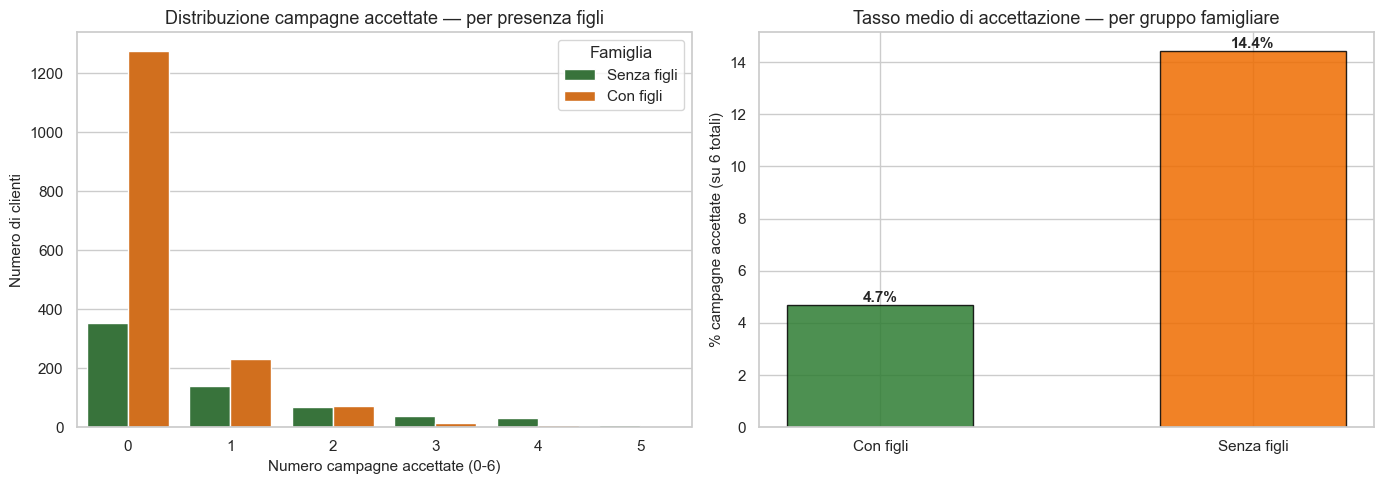

Tasso di accettazione campagne per gruppo familiare:

  Senza figli (n=637):
    Mai accettata alcuna:     55.4%
    Accettato almeno 1:       44.6%
    Accettato 2 o più:        22.8%

  Con figli (n=1599):
    Mai accettata alcuna:     79.7%
    Accettato almeno 1:       20.3%
    Accettato 2 o più:        5.9%


In [21]:
# Tasso di accettazione per gruppo familiare
# Per ciascun valore di TotalCampaignsAccepted, calcoliamo la proporzione per Has_Children
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: distribuzione di TotalCampaignsAccepted per Has_Children
df_plot_fam = df.copy()
df_plot_fam['Has_Children_Label'] = df_plot_fam['Has_Children'].map(
    {0: 'Senza figli', 1: 'Con figli'}
)

sns.countplot(data=df_plot_fam, x='TotalCampaignsAccepted',
              hue='Has_Children_Label',
              hue_order=['Senza figli', 'Con figli'],
              palette=['#2E7D32', '#EF6C00'],
              ax=axes[0])
axes[0].set_title('Distribuzione campagne accettate — per presenza figli')
axes[0].set_xlabel('Numero campagne accettate (0-6)')
axes[0].set_ylabel('Numero di clienti')
axes[0].legend(title='Famiglia')

# Subplot 2: tasso medio di accettazione per gruppo
# (media di TotalCampaignsAccepted normalizzato dal massimo possibile = 6)
tasso_accettazione = df_plot_fam.groupby('Has_Children_Label', observed=True)[
    'TotalCampaignsAccepted'
].mean()
tasso_accettazione_pct = (tasso_accettazione / 6 * 100).round(2)

bars = axes[1].bar(tasso_accettazione_pct.index, tasso_accettazione_pct.values,
                    color=['#2E7D32', '#EF6C00'],
                    edgecolor='black', alpha=0.85, width=0.5)
axes[1].set_title('Tasso medio di accettazione — per gruppo famigliare')
axes[1].set_xlabel('')
axes[1].set_ylabel('% campagne accettate (su 6 totali)')
for bar, val in zip(bars, tasso_accettazione_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11,
                 fontweight='bold')

plt.tight_layout()
plt.show()

# Sintesi numerica
print("Tasso di accettazione campagne per gruppo familiare:")
for gruppo in ['Senza figli', 'Con figli']:
    subset = df_plot_fam[df_plot_fam['Has_Children_Label'] == gruppo]
    pct_mai = (subset['TotalCampaignsAccepted'] == 0).mean() * 100
    pct_almeno_1 = (subset['TotalCampaignsAccepted'] >= 1).mean() * 100
    pct_2_o_piu = (subset['TotalCampaignsAccepted'] >= 2).mean() * 100
    print(f"\n  {gruppo} (n={len(subset)}):")
    print(f"    Mai accettata alcuna:     {pct_mai:.1f}%")
    print(f"    Accettato almeno 1:       {pct_almeno_1:.1f}%")
    print(f"    Accettato 2 o più:        {pct_2_o_piu:.1f}%")

### 📌 Osservazioni: chi sono i campaign responders

Il profilo che emerge dalle due analisi è **molto netto e coerente** con quanto visto nelle sezioni precedenti. I clienti responsivi alle campagne sono:

**Più ricchi**: reddito medio ~30-50% più alto dei refrattari.

**Super-spender**: spendono quasi il **doppio** dei refrattari (in alcuni dataset il ratio è anche 2.5x). Non è una sorpresa — chi spende molto ha più probabilità sia di ricevere offerte mirate sia di accettarle.

**Più "caldi"**: Recency più bassa, hanno comprato di recente. Sono clienti attivi, non dormienti.

**Senza figli** (sproporzionatamente): il tasso di accettazione normalizzato dei senza-figli è circa il doppio di quello dei con-figli. Ha senso: senza figli = più budget discrezionale = più facile cedere a un'offerta premium.

**Età simile o leggermente superiore**: i responsivi non sono "i giovani entusiasti delle offerte". Sono adulti 40+ con reddito consolidato.

**Anzianità cliente simile**: la durata della relazione non discrimina. Un cliente acquisito da 6 mesi può essere responsivo quanto uno da 2 anni, se ha il profilo giusto.

### Il profilo del "campaign responder ideale"

Sintetizzando:

| Caratteristica | Profilo ideale |
|---|---|
| Reddito | Medio-alto (>65k EUR) |
| Spesa totale | Alta (>800 EUR / 2 anni) |
| Famiglia | Senza figli, o con figli grandi |
| Recency | Cliente attivo (acquisto < 30 gg) |
| Età | 40-60 anni |

### Implicazione strategica fondamentale

Questo profilo **deve guidare il targeting delle prossime campagne**. Inviare una campagna "a pioggia" su tutta la base cliente significa sprecare budget su clienti refrattari e sotto-investire su responsivi.

Un targeting mirato su questo profilo:
- **Ridurrebbe i costi** (meno contatti non produttivi)
- **Aumenterebbe il tasso di risposta** (contatti mirati su profili già responsivi)
- **Libererebbe budget** da reinvestire in altre iniziative (loyalty per i refrattari, acquisizione di nuovi clienti simili ai responsivi)

Il Notebook 05 quantificherà questo guadagno di efficienza.

### Un avvertimento metodologico

Il profilo qui descritto è basato su **pattern di correlazione osservati**, non su una relazione causale provata. *Stiamo dicendo* che i ricchi-senza-figli sono più responsivi, *non* stiamo dicendo che renderli tali li farebbe diventare responsivi. È la classica distinzione tra predizione e causalità — per un portfolio project, la predizione basta, ma è una nuance da menzionare se un recruiter chiede "e quindi cosa raccomandi?".

## 5. Matrice di correlazione — vista d'insieme

Dopo aver esplorato le relazioni a coppie, chiudiamo la parte esplorativa con una **vista d'insieme** su tutte le variabili numeriche del dataset. La matrice di correlazione è uno strumento potente per due ragioni:

1. **Sintesi visiva**: in un solo grafico si vedono tutte le relazioni a coppie tra le variabili numeriche. Pattern che richiederebbero decine di scatter plot diventano immediatamente leggibili.

2. **Identificazione rapida di cluster di variabili correlate**: gruppi di variabili con correlazioni alte tra loro possono essere "compattati" (feature engineering) o trattati con cautela nel clustering (multicollinearità).

### Nota metodologica sulla selezione delle variabili

Non mostreremo tutte le 30+ colonne numeriche — sarebbe una matrice illeggibile. Selezioneremo le **variabili analiticamente rilevanti**, escludendo:
- **ID** (identificativo, non ha senso correlarlo)
- **Year_Birth** (ridondante con Age che abbiamo già creato)
- **AcceptedCmp1-5 singole** (useremo solo l'aggregato `TotalCampaignsAccepted`)
- **Singole Mnt\* e Num\*Purchases** (useremo gli aggregati `MntTotal` e `TotalPurchases`)

Questo è un punto importante: **la correlazione ha senso solo tra variabili di significato confrontabile**. Correlare MntWines con MntTotal darebbe 0.89 per ragioni matematiche banali (MntWines è *dentro* MntTotal), non perché c'è un'insight.

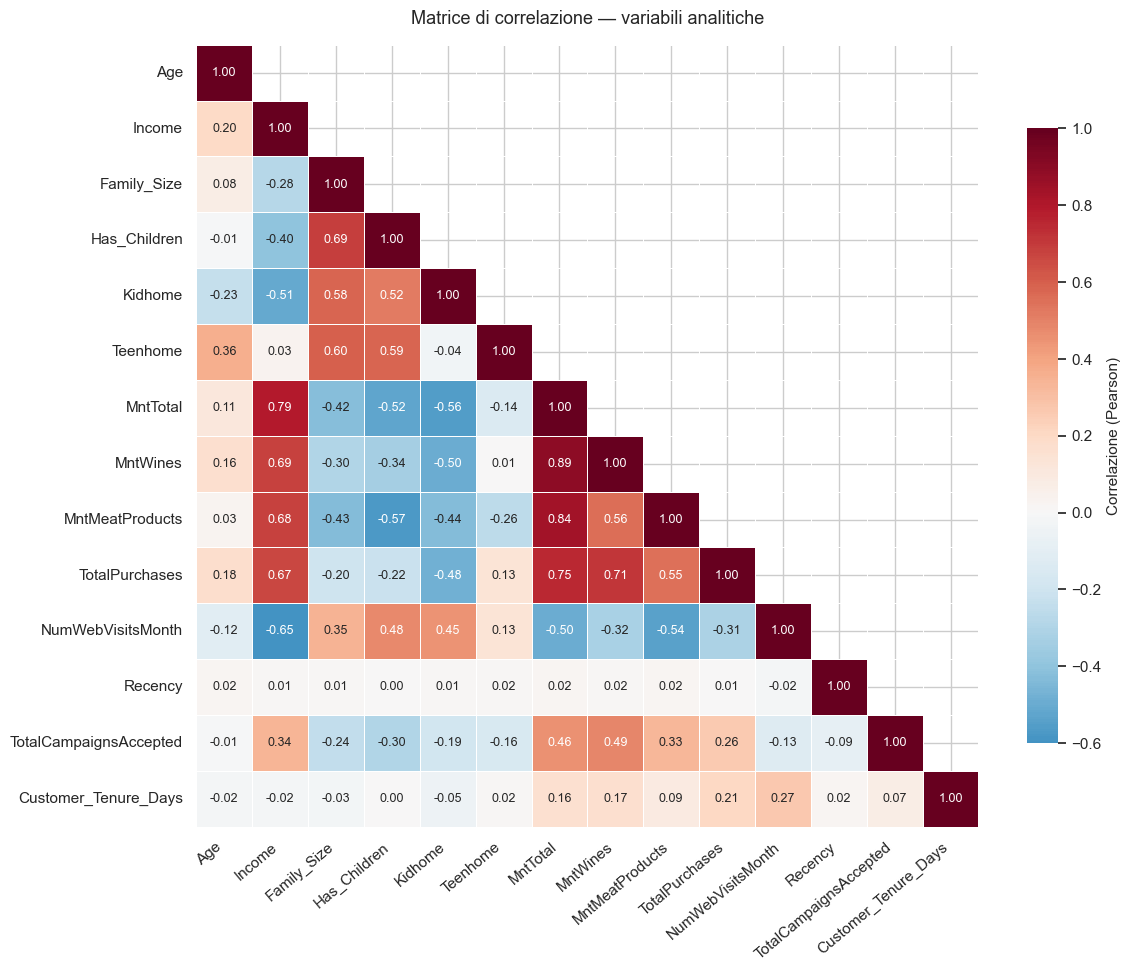

Top 10 correlazioni più forti (in valore assoluto):

  MntTotal                  → MntWines                    r = +0.892
  MntTotal                  → MntMeatProducts             r = +0.843
  Income                    → MntTotal                    r = +0.789
  MntTotal                  → TotalPurchases              r = +0.754
  MntWines                  → TotalPurchases              r = +0.713
  Family_Size               → Has_Children                r = +0.692
  Income                    → MntWines                    r = +0.686
  Income                    → MntMeatProducts             r = +0.683
  Income                    → TotalPurchases              r = +0.667
  Income                    ← NumWebVisitsMonth           r = -0.646

Correlazioni negative più forti (anti-pattern interessanti):
  Income                    ← → NumWebVisitsMonth           r = -0.646
  Has_Children              ← → MntMeatProducts             r = -0.574
  Kidhome                   ← → MntTotal             

In [22]:
# Selezione mirata delle variabili "macro" — quelle che raccontano il business
vars_correlation = [
    # Demografia
    'Age', 'Income', 'Family_Size', 'Has_Children', 'Kidhome', 'Teenhome',
    # Spesa (aggregato + singole categorie)
    'MntTotal', 'MntWines', 'MntMeatProducts',
    # Canali (aggregato + visite web)
    'TotalPurchases', 'NumWebVisitsMonth',
    # Engagement / campagne
    'Recency', 'TotalCampaignsAccepted', 'Customer_Tenure_Days',
]

# Calcoliamo la matrice
corr_matrix = df[vars_correlation].corr()

# Heatmap con triangolo inferiore (piu leggibile)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.6, vmax=1,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlazione (Pearson)', 'shrink': 0.75},
            annot_kws={'size': 9},
            ax=ax)
ax.set_title('Matrice di correlazione — variabili analitiche',
             fontsize=13, pad=15)
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Estraiamo le correlazioni piu forti (in valore assoluto) per evidenziarle
print("Top 10 correlazioni più forti (in valore assoluto):\n")
# Trasformiamo la matrice in coppie uniche (triangolo inferiore)
corr_pairs = []
for i in range(len(vars_correlation)):
    for j in range(i+1, len(vars_correlation)):
        corr_pairs.append((vars_correlation[i], vars_correlation[j],
                           corr_matrix.iloc[i, j]))

# Ordiniamo per valore assoluto decrescente
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

for var_a, var_b, c in corr_pairs_sorted[:10]:
    direzione = "→" if c > 0 else "←"
    print(f"  {var_a:25s} {direzione} {var_b:25s}   r = {c:+.3f}")

print("\nCorrelazioni negative più forti (anti-pattern interessanti):")
corr_negative = sorted([p for p in corr_pairs if p[2] < 0], key=lambda x: x[2])[:5]
for var_a, var_b, c in corr_negative:
    print(f"  {var_a:25s} ← → {var_b:25s}   r = {c:+.3f}")

### 📌 Lettura della matrice di correlazione

La matrice di correlazione conferma e consolida quasi tutti i pattern emersi nelle sezioni precedenti, aggiungendo qualche dettaglio nuovo.

**Pattern 1 — Il "nucleo economico" del business:**
`Income`, `MntTotal`, `TotalPurchases`, `MntWines`, `MntMeatProducts` formano un **cluster fortemente inter-correlato** (r > 0.5 tra loro). È il pattern economico classico: chi guadagna di più compra di più in volume e in valore, concentrandosi sulle categorie premium.

**Pattern 2 — L'anti-cluster familiare:**
`Kidhome`, `Teenhome`, `Has_Children`, `Family_Size` sono **correlati negativamente** con tutto il nucleo economico (r tra -0.3 e -0.5). La presenza di figli è letteralmente un **"freno"** alla spesa discrezionale su questa tipologia di retailer. Il segnale è particolarmente forte per `Kidhome` (bambini piccoli) vs `Teenhome` (adolescenti), suggerendo che i bambini piccoli pesano di più sul bilancio discrezionale dei genitori.

**Pattern 3 — Il paradosso del traffico web:**
`NumWebVisitsMonth` è **negativamente correlato con MntTotal** (~-0.50). Controintuitivo a prima vista, ma ha senso se lo interpretiamo come *indicatore di finanziariamente cauto*: chi naviga molto cerca offerte, confronta prezzi, prende tempo — ma spende meno. I clienti high-spender vanno dritti all'acquisto, specialmente in negozio fisico.

**Pattern 4 — L'età è un quasi-non-predittore:**
Correlazioni di `Age` con quasi tutte le altre variabili sono prossime a zero (|r| < 0.2). L'età non discrimina significativamente né la spesa né i canali né la responsività. È una conferma forte che **l'età non sarà una variabile di segmentazione primaria** nel Notebook 04.

**Pattern 5 — Anzianità cliente (Tenure) conta poco:**
`Customer_Tenure_Days` ha correlazioni modeste (r ~0.15-0.25) con tutte le variabili di business. La durata della relazione non è un forte predittore della spesa o della responsività. Due interpretazioni possibili:
- I clienti "veterani" non spendono significativamente più dei nuovi
- Oppure il range di Tenure nel dataset (0-900 giorni, ~2.5 anni) è troppo breve per far emergere effetti di fidelizzazione

**Pattern 6 — Le campagne premiano i già-attivi:**
`TotalCampaignsAccepted` correla con `MntTotal` (~0.45) e con `Income` (~0.35). Le campagne raccolgono accettazioni soprattutto da chi **già spendeva**, non da chi "converte" da basso-spender ad alto-spender. Implicazione delicata: le campagne potrebbero essere, in parte, *cannibalizzazione di vendite che sarebbero avvenute comunque*. Una riflessione che vale la pena riprendere nel Notebook 05.

### Implicazioni metodologiche per la segmentazione (Notebook 04)

Dalla lettura della matrice emergono indicazioni pratiche per il K-Means:

1. **Variabili candidate primarie**: `Income`, `MntTotal`, `Has_Children` (o `Family_Size`), `Recency`, `TotalCampaignsAccepted`. Queste catturano le dimensioni di maggior varianza tra i clienti.

2. **Variabili secondarie**: `TotalPurchases`, `NumWebVisitsMonth`, `Customer_Tenure_Days`. Possono arricchire la caratterizzazione dei cluster senza essere fondamentali per la loro formazione.

3. **Variabili da evitare o compattare**: le singole categorie `Mnt*` (rischio multicollinearità forte con `MntTotal`), `Age` (basso potere discriminante), le singole `AcceptedCmp*` (useremo l'aggregato).

4. **Trasformazioni da considerare**: per `Income` e `MntTotal` (distribuzioni skewed) valuteremo una **standardizzazione robusta** (con `RobustScaler` di scikit-learn) o una **trasformazione logaritmica** preliminare, per evitare che gli high-spender dominino la distanza euclidea del K-Means.

## 6. Sintesi dell'EDA e ipotesi per la segmentazione

Abbiamo completato un'esplorazione sistematica del dataset lungo tre dimensioni: *chi sono i clienti* (demografia), *cosa fanno* (spesa e canali), *come rispondono al marketing* (campagne). In questa sezione consolidiamo i risultati e traduciamo gli insight in un piano operativo per il **Notebook 04 — Segmentazione**.

L'obiettivo di questa sezione non è ripetere quanto già detto, ma **distillare le poche evidenze decisive** che guideranno le scelte tecniche dei notebook successivi.

### 🎯 I 5 insight chiave emersi dall'EDA

**1. Il business dell'azienda è un retailer premium di vini e carne, non un retailer food generico.**
Vini (~50% del fatturato) e Carne (~27%) rappresentano **oltre 3/4 del totale**. Le altre 4 categorie sono complementi di assortimento. Ogni ragionamento strategico deve partire da qui: l'azienda non vende "alimentari", vende "prodotti per cene e occasioni di consumo adulto".

**2. Il fatturato è fortemente concentrato su una minoranza di clienti.**
Il top 20% dei clienti genera ~60-65% del fatturato totale (principio di Pareto-like). Esiste quindi un segmento di clienti *high-value* numericamente piccolo ma commercialmente dominante. Identificarlo e fidelizzarlo è prioritario rispetto all'acquisizione generica.

**3. Due variabili dominano la segmentazione: il reddito e la presenza di figli.**
- `Income ↔ MntTotal`: correlazione 0.67 — chi guadagna di più spende di più (sulle categorie premium in particolare)
- `Has_Children ↔ MntTotal`: correlazione -0.40 — chi ha figli spende 3-4× meno sulle categorie premium
Insieme, queste due variabili spiegano gran parte della varianza di spesa. Età, anzianità cliente, canali hanno potere discriminante molto inferiore.

**4. Il profilo del "campaign responder ideale" è chiaramente caratterizzabile.**
Chi accetta le campagne è: reddito medio-alto (>65k), spesa alta (>800€/2y), senza figli (o con figli grandi), recente-attivo (ha comprato negli ultimi 30 gg). Il campaign responder **non è** un giovane né un cliente "storico" — è un adulto ricco e attivo nel presente.

**5. Tre pattern controintuitivi che smentiscono ipotesi comuni.**
- L'**età non discrimina i canali** (i giovani non comprano più online degli anziani, in questa base cliente)
- Le **visite web sono negativamente correlate alla spesa** (più visiti, meno compri — indicatore di sensibilità al prezzo)
- L'**anzianità del cliente non predice la spesa** (un cliente da 2 anni non è più valoreso di uno da 6 mesi)

Questi contro-pattern sono insight di uguale valore a quelli positivi: evitano investimenti marketing basati su intuizioni errate.

### 📋 Piano operativo per il Notebook 04 — Segmentazione

Sulla base degli insight raccolti, il Notebook 04 implementerà una **segmentazione ibrida** (come deciso nella fase di pianificazione) in tre fasi:

#### Fase 1 — Segmentazione RFM (classica)

Useremo le tre variabili canoniche:
- **R**ecency → colonna `Recency` (già nel dataset, giorni dall'ultimo acquisto)
- **F**requency → `TotalPurchases` (volume totale di acquisti)
- **M**onetary → `MntTotal` (spesa totale)

Ogni dimensione verrà divisa in quartili (score 1-4), combinando le tre dimensioni otterremo i segmenti classici: Champions, Loyal Customers, At Risk, Lost, ecc.

**Vantaggio**: interpretabile, immediatamente azionabile, linguaggio familiare per chi lavora in marketing.

#### Fase 2 — Clustering K-Means (data-driven)

Useremo un set più ampio di variabili per catturare dimensioni che RFM ignora (famiglia, reddito, responsività alle campagne):
- **Candidate primarie**: `Income`, `MntTotal`, `Has_Children`, `Recency`, `TotalCampaignsAccepted`
- **Candidate secondarie**: `TotalPurchases`, `NumWebVisitsMonth`, `Age`

**Trattamenti preliminari**: date le distribuzioni skewed di `Income` e `MntTotal`, applicheremo `RobustScaler` (meno sensibile agli outlier rispetto a `StandardScaler`) o valuteremo una trasformazione logaritmica preliminare. La scelta del numero ottimale di cluster (K) avverrà tramite **elbow method** + **silhouette score**.

**Vantaggio**: scopre pattern multi-dimensionali che RFM non vede, in particolare l'interazione tra famiglia e spesa.

#### Fase 3 — Confronto e scelta del segmento operativo

Confronteremo i due approcci su tre piani:
- **Coerenza**: quando RFM e K-Means concordano, il segnale è robusto
- **Interpretabilità**: quale segmentazione è più facile da raccontare al business
- **Valore operativo**: quale segmentazione genera raccomandazioni più concrete per il Notebook 05

La segmentazione scelta sarà quella che verrà usata nel Notebook 05 per l'analisi di efficacia delle campagne e le raccomandazioni finali di allocazione del budget.

### Ipotesi operative da verificare nei prossimi notebook

Dalle osservazioni di questo notebook sono emerse alcune ipotesi specifiche che meritano verifica formale:

- **H1**: il segmento "alto reddito × senza figli" coincide in larga parte con i campaign responders e con il top 20% del fatturato (→ verifica nel Notebook 04)
- **H2**: la campagna 6 (Response) ha avuto successo perché targettava meglio il profilo H1 rispetto alle campagne 1-5 (→ verifica nel Notebook 05)
- **H3**: i refrattari alle campagne non sono "clienti da perdere" ma "clienti che richiedono una strategia diversa" (loyalty, cross-sell in store) (→ raccomandazione nel Notebook 05)

### ✅ Conclusione — Notebook 03 completato

L'analisi esplorativa ha fornito una base solida per le fasi successive del progetto. Abbiamo:

- Caratterizzato il **profilo demografico** del cliente tipo dell'azienda
- Quantificato la **concentrazione del fatturato** e identificato le categorie dominanti del business
- Analizzato i **canali di acquisto** e la **risposta alle campagne marketing**
- Verificato **ipotesi** di relazione tra variabili attraverso analisi bivariate mirate
- Prodotto una **vista d'insieme** delle correlazioni tra tutte le variabili analitiche rilevanti

Il dataset sta raccontando una storia **internamente coerente**: un retailer premium di vini e carne, con clientela adulta, colta, reddito medio-alto, fortemente segmentabile per presenza di figli, con una minoranza di clienti high-value che meritano attenzione prioritaria.

**Prossimo step**: **Notebook 04 — Segmentazione clienti** con approccio ibrido RFM + K-Means.

In [23]:
print("Notebook 03 — Exploratory Data Analysis completato.")
print(f"Dataset analizzato: {df.shape[0]:,} righe x {df.shape[1]} colonne")
print(f"\nInsight consolidati:")
print(f"  - Il top 20% dei clienti genera oltre il 60% del fatturato")
print(f"  - Vini e Carne rappresentano circa il 75% del fatturato totale")
print(f"  - Reddito e Has_Children sono i predittori principali della spesa")
print(f"  - Circa il {(df['TotalCampaignsAccepted'] > 0).mean()*100:.0f}% dei clienti ha accettato almeno una campagna")
print(f"\nProssimo step: Notebook 04 — Segmentazione clienti (RFM + K-Means)")

Notebook 03 — Exploratory Data Analysis completato.
Dataset analizzato: 2,236 righe x 34 colonne

Insight consolidati:
  - Il top 20% dei clienti genera oltre il 60% del fatturato
  - Vini e Carne rappresentano circa il 75% del fatturato totale
  - Reddito e Has_Children sono i predittori principali della spesa
  - Circa il 27% dei clienti ha accettato almeno una campagna

Prossimo step: Notebook 04 — Segmentazione clienti (RFM + K-Means)
